# Benchmarking Four Planning Models on a Shared Task

This notebook extends the previous three-way benchmark with a **fourth** model: the algorithm from
Furlong, Dumont, Antonova, Orchard & Eliasmith, *"Compositional neurosymbolic representations enable
efficient active exploration"*, **Nature Communications**, published 22 August 2026
([s41467-026-75703-4](https://www.nature.com/articles/s41467-026-75703-4)) — the **SSP-BO** algorithm,
implemented from the uploaded `ssp-bayesopt-main` repository.

| Line of work | Chosen for this benchmark | Why |
|---|---|---|
| Cognitive-map learners (CML, GCML) | **GCML** | Strictly extends CML (same embedding backbone + affordance network + imagination-based planning); its paper targets exactly the goal-change adaptation this benchmark tests. |
| RNN planning models (Jensen `planning_code`, `tinyRNN`) | **Jensen-RNN** | Directly a spatial-navigation planning model with learned rollouts. `tinyRNN` fits minimal RNNs by supervised behavioural cloning to two-step *bandit* choice data — different task, different training paradigm. |
| Active Predictive Coding (`apc-vision`) | **APC**, per the paper's Section 6 | The repo is a different APC application (glimpse-based image parsing, TF2). The paper's own Section 6 is a multi-room building-navigation task with options + MPC, which is what's implemented here. |
| **Compositional neurosymbolic active exploration (`ssp-bayesopt`)** | **SSP-BO**, via its own `SSPTrajectoryAgent` | **New in this notebook.** Bayesian optimization with a Bayesian-linear-regression surrogate over Spatial Semantic Pointer embeddings. Enters the benchmark as a *trajectory-space planner*, which is the repo's own `ssp-traj` agent — see Section 6 for why that is the honest mapping and not a forced one. |

## The one thing to read before trusting any number below

**SSP-BO is not a navigation-policy learner, and it is not doing the same kind of work as the other
three.** It is a sample-efficient *black-box optimizer*: its headline claim is that sample selection
costs `O(d²)` in a fixed embedding dimension rather than `O(n³)` in the number of observations, giving
constant time and memory per step over an unbounded lifetime.

Putting it on a steps-to-goal axis against three amortized planners is therefore only meaningful if the
asymmetry is stated rather than hidden:

- **GCML, APC, Jensen-RNN amortize.** They learn a map / model / policy once, then emit a path for each
  new goal essentially instantly.
- **SSP-BO re-solves from scratch for every goal.** It spends ~90 rollouts per goal optimizing a
  waypoint plan, and keeps nothing between goals.

So Section 8 reports SSP-BO on the shared axis (steps/optimal) *and* on the cost axis it actually trades
against (planning wall-clock, rollouts consumed), and **Section 9 puts it on its own home turf** —
sample-selection time as the observation count `n` grows, head-to-head against the GP baseline shipped
in the same repo. That is where its actual claim lives, and it is the section that most fairly represents
the paper.

## What's benchmarked

- **Steps-to-goal vs. optimal** (BFS shortest path), across a shared sequence of goal relocations on one
  shared building.
- **Planning wall-clock per goal** — total compute spent deciding, across all four models.
- **Sample-selection time vs. n** — SSP-BO vs. GP-BO (Section 9), the paper's own claim.

## A note on what was and wasn't verified

The authoring sandbox had no internet, so GCML, APC and SSP-BO — pure NumPy/SciPy/scikit-learn — were
**directly executed and debugged there**, while Jensen-RNN, which needs PyTorch, could only be reviewed
line-by-line for shape and logic correctness. In the run whose outputs are saved below, **all four models
executed**. Jensen-RNN's number is still the one to treat with most caution, but no longer because it is
untested: because it **failed**.

Results of the run saved in this notebook (3×3 rooms, 15 goal relocations × 3 repeats, same building):

| Model | steps/optimal | planning s/goal | goals reached |
|---|---|---|---|
| GCML | 1.649 ± 1.315 | 0.026 | 45/45 |
| APC | 1.361 ± 0.966 | 0.001 | 45/45 |
| Jensen-RNN | 23.992 ± 8.629 | 0.033 | **0/45** |
| SSP-BO | 1.180 ± 0.449 | 8.116 | 45/45 |

Section 9's scaling result: after a ~120 ms warm-up over its first few steps, SSP-BO settles at ~23–28
ms/step and stays there out to n=262, while GP-BO climbs from ~72 ms to ~220 ms — a **7.9×** gap at the
end of the run, 5.9× in total wall-clock (7.5 s vs. 44.5 s), and still widening.

Two things worth reading carefully. **Jensen-RNN reached the goal 0 times in 45 runs**, hitting the
150-step cap every time with an identical score in all three repeats; at 400 meta-training episodes and
64 hidden units this is an under-trained re-implementation, not a measurement of the published model.
And **the three working models are separated by less than their own spread** — GCML's ±1.315 is wider
than the gap between any two of them — so the bar chart in Section 8 does not rank them. Read the
standard deviations, and read the cost column next to them.

## 0. Setup

In [ ]:
!pip -q install torch numpy scipy scikit-learn matplotlib networkx --upgrade 2>/dev/null

In [ ]:
import numpy as np
import random
import time
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque, defaultdict
from scipy.optimize import minimize

warnings.filterwarnings('ignore')  # sklearn's GP emits ConvergenceWarnings in Section 9

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('setup ok')

setup ok


## 1. Shared Task: Multi-Room Building Navigation

A compositional 'four-rooms'-style building (Sutton, Precup & Singh 1999, generalized to an `Rx x Ry` grid of rooms). This is deliberately the **same task family used natively by two of the four papers**: it matches Jensen et al.'s grid-maze-with-relocating-goal task, and it *is* essentially the 'multi-rooms building' task from APC's own hierarchical-planning section (Rao, Gklezakos & Sathish, Section 6) -- which is what makes a genuine four-way comparison possible rather than forcing an unfamiliar task onto any of the models.

Each room is an open `r x r` block of cells; adjacent rooms are connected by exactly one doorway at the middle of their shared wall. Walls are fully observed (locally) at every step; only the goal location is hidden and relocates periodically to test adaptation speed, mirroring both Jensen et al.'s repeated within-episode reward relocation and APC's 'goal-changing navigation' experiment (their Fig. 10a).

In [ ]:
import numpy as np
import networkx as nx

DIRS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # 0=N,1=S,2=W,3=E
DIR_NAMES = ['N', 'S', 'W', 'E']
OPP = {0: 1, 1: 0, 2: 3, 3: 2}


class MultiRoomMaze:
    """A compositional 'four-rooms'-style building: Rx x Ry rooms, each r x r cells,
    with a single doorway at the middle of each shared wall between adjacent rooms
    (Sutton, Precup & Singh 1999 'four rooms' domain, generalized to an Rx x Ry grid).
    This is the shared task substrate for GCML, Jensen-RNN, and APC: it matches
    Jensen et al.'s grid-maze-with-relocating-goal task, and it *is* literally the
    'multi-rooms building' task from the APC paper's hierarchical-planning section
    (Rao, Gklezakos & Sathish 2022/2024, Section 6), which is exactly what makes a
    fair three-way comparison possible.
    """

    def __init__(self, Rx=3, Ry=3, room_size=4, max_steps=150):
        self.Rx, self.Ry = Rx, Ry
        self.r = room_size
        self.H = Rx * room_size
        self.W = Ry * room_size
        self.max_steps = max_steps

    # ---- construction -----------------------------------------------------
    def _build(self, seed):
        rng = np.random.RandomState(seed)
        G = nx.grid_2d_graph(self.H, self.W)
        # remove all edges that cross a room boundary...
        to_remove = []
        for (r1, c1), (r2, c2) in G.edges():
            room1 = (r1 // self.r, c1 // self.r)
            room2 = (r2 // self.r, c2 // self.r)
            if room1 != room2:
                to_remove.append(((r1, c1), (r2, c2)))
        G.remove_edges_from(to_remove)
        # ...then re-add exactly one doorway edge per pair of adjacent rooms, at the
        # middle of their shared wall (classic four-rooms construction)
        doors = {}  # (room, direction_idx) -> bool, for the affordance/adjacency api
        mid = self.r // 2
        for rx in range(self.Rx):
            for ry in range(self.Ry):
                # door to the room below (S)
                if rx + 1 < self.Rx:
                    r1 = rx * self.r + self.r - 1
                    c1 = ry * self.r + mid
                    r2 = r1 + 1
                    c2 = c1
                    G.add_edge((r1, c1), (r2, c2))
                # door to the room to the right (E)
                if ry + 1 < self.Ry:
                    r1 = rx * self.r + mid
                    c1 = ry * self.r + self.r - 1
                    r2 = r1
                    c2 = c1 + 1
                    G.add_edge((r1, c1), (r2, c2))
        assert nx.is_connected(G)
        return G

    def room_of(self, cell):
        r, c = cell
        return (r // self.r, c // self.r)

    def local_of(self, cell):
        r, c = cell
        return (r % self.r, c % self.r)

    def room_neighbors(self, room):
        """Which of the 4 directions have an actual door out of this room, and to where."""
        rx, ry = room
        out = {}
        if rx > 0: out[0] = (rx - 1, ry)          # N
        if rx + 1 < self.Rx: out[1] = (rx + 1, ry)  # S
        if ry > 0: out[2] = (rx, ry - 1)          # W
        if ry + 1 < self.Ry: out[3] = (rx, ry + 1)  # E
        return out

    # ---- episode api --------------------------------------------------
    def new_context(self, seed):
        self.G = self._build(seed)
        nodes = list(self.G.nodes())
        rng = np.random.RandomState(seed + 999)
        self.start = nodes[rng.randint(len(nodes))]
        self.goal = nodes[rng.randint(len(nodes))]
        while self.goal == self.start:
            self.goal = nodes[rng.randint(len(nodes))]
        self.opt_len = nx.shortest_path_length(self.G, self.start, self.goal)
        self.goal_room = self.room_of(self.goal)
        return self.start, self.goal, self.opt_len

    def reset(self):
        self.pos = self.start
        self.t = 0
        return self._wall_obs()

    def _wall_obs(self):
        # fully-observed local connectivity (walls are NOT hidden in Jensen et al.'s task
        # -- only the reward/goal location is; see environment.jl: wall info is given
        # directly as an input ("Nwall_in ... provide full info"))
        r, c = self.pos
        obs = []
        for dr, dc in DIRS:
            nxt = (r + dr, c + dc)
            obs.append(1.0 if self.G.has_edge(self.pos, nxt) else 0.0)
        return np.array(obs, dtype=np.float32)

    def step(self, a):
        dr, dc = DIRS[a]
        nxt = (self.pos[0] + dr, self.pos[1] + dc)
        if self.G.has_edge(self.pos, nxt):
            self.pos = nxt
        self.t += 1
        reached = (self.pos == self.goal)
        reward = 1.0 if reached else -0.02
        done = reached or (self.t >= self.max_steps)
        return self._wall_obs(), reward, done, reached

    def state_index(self, cell):
        r, c = cell
        return r * self.W + c

    @property
    def n_states(self):
        return self.H * self.W


In [ ]:
env_demo = MultiRoomMaze(Rx=3, Ry=3, room_size=4, max_steps=150)
s, g, L = env_demo.new_context(seed=0)
print('start', s, 'goal', g, 'optimal steps', L, 'n_states', env_demo.n_states)


start (7, 8) goal (8, 5) optimal steps 6 n_states 144


## 2. Optimal Baseline (BFS) -- used throughout for the steps/optimal ratio

In [ ]:
def optimal_steps(env, a, b):
    return nx.shortest_path_length(env.G, a, b)


## 3. Model 1 -- GCML (chosen over CML)

**Why GCML over CML:** GCML strictly extends CML's mechanism (same self-supervised vector-embedding backbone) with an affordance network `G` and a noisy multi-rollout ('theta-cycle') imagination planner, and its own paper's title is literally 'goal-directed imagination and planning' -- directly targeting the adaptation-to-goal-change comparison this benchmark cares about, which is exactly where it improves on CML.

**Ported faithfully from `GCML-main/gcml_abstract_graph.ipynb`** (the `Agent` class and `network_train_process` are a 1:1 port to NumPy -- the original runs entirely under `torch.no_grad()`, i.e. it is not backprop-trained, so nothing is lost in translation). Two porting corrections were needed and are documented inline in the code below:

1. **Actions are per directed-edge, not a shared compass action space.** The original graph task assigns every directed edge its own action id. Using a small shared action set (N/S/E/W, all cells sharing the same 4 action vectors) breaks the mechanism -- verified directly: with shared compass actions the mean optimality ratio on a 32-node graph was **~7.5x optimal**; switching to per-edge actions (matching the real repo) brought it to **~1.01x optimal**, i.e. essentially exactly reproducing the paper's headline result.
2. **Planning uses frozen weights.** The original notebook pretrains via random-walk trajectories, then plans with the map frozen (still under `torch.no_grad()`) -- continuing to learn during planning/evaluation was found to destabilize the embedding.

In [ ]:
import numpy as np


class GCMLAgent:
    """Ported from GCML-main/gcml_abstract_graph.ipynb (Agent class + network_train_process +
    move_one_step_traj / network_plan_process), adapted from graph nodes to maze cells.

    Learning rule (exactly the local, backprop-free update from the paper -- 'with
    torch.no_grad()' in the original, so this is a 1:1 port to NumPy, not an approximation):
        s_predict = Q[:,o_pre] + V[:,a]
        utility   = W @ (Q[:,o_next] - Q[:,o_pre])
        affordance= G @ Q[:,o_next]
        pred_error = Q[:,o_next] - s_predict
        Q[:,o_next] += -0.1 * pred_error
        V[:,a]      += 0.01 * pred_error
        W           += 0.01 * (onehot(a) - utility) outer (Q[:,o_next]-Q[:,o_pre])
        G           += 0.0005 * (true_affordance(o_pre) - affordance) outer Q[:,o_pre]

    Planning ('theta cycles'): several noisy imagined rollouts are generated purely by
    vector arithmetic in embedding space (s = Q[loc] + V @ cumulative_action_count), gated
    by the *real* affordance only at the first imagined step and by the *learned* affordance
    net G for subsequent steps (this is the 'imagination' -- no further queries to the real
    environment). The best-scoring rollout's first action is executed, then the agent
    replans from scratch after observing the real outcome (receding-horizon / MPC-style).
    """

    def __init__(self, n_states, n_actions=4, s_dim=64, seed=0):
        rng = np.random.RandomState(seed)
        self.n_states, self.n_actions, self.s_dim = n_states, n_actions, s_dim
        self.Q = 1.0 * rng.randn(s_dim, n_states).astype(np.float32)
        self.V = 0.1 * rng.randn(s_dim, n_actions).astype(np.float32)
        self.W = 0.1 * rng.randn(n_actions, s_dim).astype(np.float32)
        self.G = 0.1 * rng.randn(n_actions, s_dim).astype(np.float32)
        self.reward = np.zeros(n_states, dtype=np.float32)
        self.rng = rng

    def set_goal(self, goal_idx):
        self.reward[:] = 0.0
        self.reward[goal_idx] = 1.0

    def observe_transition(self, o_pre, a, o_next, true_affordance_pre):
        # true_affordance_pre: length-n_actions 0/1 vector of which actions are actually
        # available at o_pre (matches env.affordance[o_pre] in the original notebook)
        s_pre, s_next = self.Q[:, o_pre], self.Q[:, o_next]
        s_predict = s_pre + self.V[:, a]
        utility = self.W @ (s_next - s_pre)
        affordance = self.G @ s_next

        pred_error = s_next - s_predict
        state_diff = s_next - s_pre

        self.Q[:, o_next] += -0.1 * pred_error
        self.V[:, a] += 0.01 * pred_error

        desired = np.zeros(self.n_actions, dtype=np.float32); desired[a] = 1.0
        self.W += 0.01 * np.outer(desired - utility, state_diff)
        self.G += 0.0005 * np.outer(true_affordance_pre - affordance, s_pre)

    def _rollout(self, loc_idx, affordance_now, forbidden_now, theta_cycle_num=5,
                 traj_len=6, noise_sigma=0.2):
        # NOTE on porting from the original graph task: in GCML-main's abstract-graph
        # notebook, every action is a *unique directed edge id*, so masking out
        # "already-used actions" for the rest of a path naturally means "don't
        # retraverse this specific edge" -- a sensible no-repeated-edge heuristic.
        # Here the action space is a small fixed compass (N/S/W/E) shared by every
        # cell, so that same rule would forbid, e.g., ever moving north again for the
        # rest of the path after the first northward step -- it exhausts all 4
        # actions almost immediately and traps the agent. The maze-appropriate
        # equivalent (used below) is the standard "don't immediately reverse your
        # last move" rule: `forbidden_now` is just the opposite of the last action
        # taken in the real trajectory (or empty at an episode's first step), applied
        # only at step 0 of the imagined rollout (matching where the original code
        # applies its own real-affordance mask); within a single imagined rollout we
        # still avoid repeating an action already tried *in that same rollout*.
        Qo_t = self.Q[:, loc_idx]
        u_star = self.W @ self.Q[:, np.argmax(self.reward)]  # 'goal direction' utility target

        best_reward, best_first_action = -1e9, None
        for _ in range(theta_cycle_num):
            a_t = np.zeros(self.n_actions, dtype=np.float32)
            used_this_rollout = set()
            traj_reward, first_action = 0.0, None
            for step_i in range(traj_len):
                s_pre = Qo_t + self.V @ a_t
                utility = -(self.W @ s_pre) + u_star
                g_aff = self.G @ s_pre
                utility = utility + np.random.randn(self.n_actions) * max(np.max(utility), 1e-6) * noise_sigma
                if step_i == 0:
                    mask = affordance_now.copy()
                    for prev_a in forbidden_now:
                        mask[prev_a] = 0.0
                else:
                    mask = g_aff.copy()
                for prev_a in used_this_rollout:
                    mask[prev_a] = 0.0
                masked_utility = utility * mask
                if np.all(masked_utility == 0):
                    remaining = np.where(mask > 0)[0]
                    action_idx = int(np.random.choice(remaining)) if len(remaining) else int(np.argmax(utility))
                else:
                    action_idx = int(np.argmax(masked_utility))
                if first_action is None:
                    first_action = action_idx
                used_this_rollout.add(action_idx)
                a_t[action_idx] += 1.0
                s_check = Qo_t + self.V @ a_t
                if np.linalg.norm(s_check - self.Q[:, np.argmax(self.reward)]) < 1e-2:
                    traj_reward += 5.0 - 0.1 * (step_i + 1)  # bonus for (imagined) arrival, path-length penalty
                    break
                else:
                    traj_reward -= 0.1
            if traj_reward > best_reward:
                best_reward, best_first_action = traj_reward, first_action
        return best_first_action

    def plan_action(self, loc_idx, affordance_now, forbidden_now):
        return self._rollout(loc_idx, affordance_now, forbidden_now)


In [ ]:
import numpy as np


def build_edge_actions(env):
    """GCML represents each *directed edge* as its own action (see edges_from_adjacency
    in the original notebook) rather than a small shared compass action space -- this
    matters a lot: it lets V[:,a] encode a context-specific displacement rather than
    forcing e.g. every 'move north' anywhere in the maze to share one vector, which is
    what the original algorithm was actually built and tuned for (confirmed: swapping
    in this scheme took mean-optimality-ratio from ~7.5x to ~1.01x on the graph task)."""
    action_indices = {}
    node_actions = {}
    action_to_node = {}
    idx = 0
    for u in env.G.nodes():
        for v in env.G.neighbors(u):
            action_indices[(u, v)] = idx
            node_actions.setdefault(u, []).append(idx)
            action_to_node[idx] = v
            idx += 1
    return action_indices, node_actions, action_to_node, idx


def affordance_vec(node_actions, n_actions, cell):
    v = np.zeros(n_actions, dtype=np.float32)
    for a in node_actions.get(cell, []):
        v[a] = 1.0
    return v


def random_walk_pretrain(env, agent, node_actions, action_to_node, n_steps=60000, seed=0):
    """Matches the real notebook's workflow: learn Q/V/W/G from random-walk exploration
    BEFORE any goal-directed planning is attempted."""
    rng = np.random.RandomState(seed)
    env.reset()
    cell = env.pos
    for _ in range(n_steps):
        aff = affordance_vec(node_actions, agent.n_actions, cell)
        a = int(rng.choice(node_actions[cell]))
        nxt = action_to_node[a]
        agent.observe_transition(env.state_index(cell), a, env.state_index(nxt), aff)
        cell = nxt


def run_episode_frozen(env, agent, node_actions, action_to_node, reverse_action, max_steps=150):
    """Planning with FROZEN Q/V/W/G, matching the real notebook (planning cells run under
    'with torch.no_grad()' -- no further learning happens during evaluation/planning)."""
    n_actions = agent.n_actions
    env.reset()
    cell = env.pos
    last_action = None
    for steps in range(1, max_steps + 1):
        aff = affordance_vec(node_actions, n_actions, cell)
        forbidden = [reverse_action[last_action]] if last_action is not None else []
        a = agent.plan_action(env.state_index(cell), aff, forbidden)
        cell = action_to_node[a]
        last_action = a
        if cell == env.goal:
            return steps
    return max_steps


In [ ]:
# quick demo: pretrain on the room maze via random walk, then plan to the goal with frozen weights
demo_env = MultiRoomMaze(Rx=3, Ry=3, room_size=4, max_steps=150)
s, g, L = demo_env.new_context(seed=0)
action_indices, node_actions, action_to_node, n_actions = build_edge_actions(demo_env)
reverse_action = {a: action_indices[(v, u)] for (u, v), a in action_indices.items()}
gcml_demo = GCMLAgent(n_states=demo_env.n_states, n_actions=n_actions, s_dim=64, seed=0)
random_walk_pretrain(demo_env, gcml_demo, node_actions, action_to_node, n_steps=60000, seed=1)
gcml_demo.set_goal(demo_env.state_index(g))
steps = run_episode_frozen(demo_env, gcml_demo, node_actions, action_to_node, reverse_action)
print(f'GCML demo: {steps} steps vs {L} optimal (ratio {steps/L:.2f})')


GCML demo: 6 steps vs 6 optimal (ratio 1.00)


## 4. Model 2 -- APC (adapted to its own paper's hierarchical-planning task)

The `apc-vision` repo implements a different application of APC (glimpse-based image parsing, TensorFlow 2 -- see the discussion section for why that's excluded from this benchmark). The APC **paper itself** (Rao, Gklezakos & Sathish, Neural Computation 36(1), 2024 / arXiv:2210.13461) has a second application, **Section 6, 'Application to Hierarchical Planning'**, that is exactly a multi-room building navigation task with:

- eight reusable low-level 'option' policies (here: four, one per room type since we use a single room template) trained via REINFORCE to navigate to fixed local subgoals (there: room corners; here: the room's doorways, functionally equivalent reusable local targets) within a generic room, reused at every location in the building;
- a higher-level state-transition model `Fs` predicting the next abstract state (room) given the current room and chosen option, learned from collected rollouts (there: an LSTM trained by gradient descent; here: a tabular visitation-count estimate -- functionally the same role for a near-deterministic abstract transition, fully inspectable and needing no backprop);
- random-shooting **model-predictive control**: sample many random option sequences, roll them out through the learned `Fs`, execute the first option of the best-scoring sequence, replan every step -- exactly as described in the paper's Section 6.2.

In [ ]:
import numpy as np

N, S, W, E = 0, 1, 2, 3          # room-level directions (match env's room_neighbors keys)
PRIM = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # primitive N,S,W,E moves


class OptionPolicy:
    """A reusable low-level policy that navigates from anywhere in a generic r x r room
    to the doorway on a given side. Ported in spirit from APC Section 6: 'eight embedding
    vectors A1..A8 were trained using REINFORCE-based RL to generate ... policies to
    navigate to each of the four corners of room types R1 and R2.' We use a single room
    type and represent the (small, tabular) policy directly rather than generating it via
    a hypernetwork from a continuous embedding -- same mechanism (REINFORCE-trained,
    reused across every room in the building), simplified for tractability/testability
    (see notebook discussion for the fidelity trade-off)."""

    def __init__(self, room_size, target_local, seed=0):
        self.r = room_size
        self.target = target_local
        self.rng = np.random.RandomState(seed)
        self.theta = np.zeros((room_size * room_size, 4), dtype=np.float64)  # logits per local cell

    def _idx(self, local):
        return local[0] * self.r + local[1]

    def _softmax(self, s):
        z = self.theta[s] - self.theta[s].max()
        p = np.exp(z)
        return p / p.sum()

    def act(self, local, greedy=False):
        s = self._idx(local)
        p = self._softmax(s)
        a = int(np.argmax(p)) if greedy else int(self.rng.choice(4, p=p))
        return a

    def train(self, n_episodes=400, max_steps=25, lr=0.2, gamma=0.95):
        r = self.r
        for ep in range(n_episodes):
            start = (self.rng.randint(r), self.rng.randint(r))
            traj = []
            loc = start
            for t in range(max_steps):
                s = self._idx(loc)
                a = self.act(loc)
                dr, dc = PRIM[a]
                nxt = (loc[0] + dr, loc[1] + dc)
                if not (0 <= nxt[0] < r and 0 <= nxt[1] < r):
                    nxt = loc  # bump into outer wall, stay put
                reward = 1.0 if nxt == self.target else -0.02
                traj.append((s, a, reward))
                loc = nxt
                if loc == self.target:
                    break
            # REINFORCE with a simple running-average baseline
            G = 0.0
            returns = []
            for (s, a, rew) in reversed(traj):
                G = rew + gamma * G
                returns.append(G)
            returns.reverse()
            baseline = np.mean(returns)
            for (s, a, rew), G in zip(traj, returns):
                p = self._softmax(s)
                grad = -p
                grad[a] += 1.0  # d log pi(a|s) / d theta = onehot(a) - softmax
                self.theta[s] += lr * (G - baseline) * grad


class RoomTransitionModel:
    """The higher-level state-transition network Fs from APC Section 6 ('trained to
    predict the next higher-level state Rt+1 given current higher-level state Rt and
    action At'), implemented here as a tabular model learned by visitation counting
    instead of an LSTM -- since executing an option is (with a well-trained low-level
    policy) close to deterministic given the true room adjacency, a count-based estimate
    plays the same functional role for MPC while being fully inspectable and needing no
    gradient-based training."""

    def __init__(self):
        self.counts = {}  # (room, direction) -> {next_room: count}

    def observe(self, room, direction, next_room):
        d = self.counts.setdefault((room, direction), {})
        d[next_room] = d.get(next_room, 0) + 1

    def predict(self, room, direction):
        d = self.counts.get((room, direction))
        if not d:
            return room  # no data yet -> assume no change (conservative)
        return max(d.items(), key=lambda kv: kv[1])[0]


def mpc_plan(room, goal_room, room_neighbors_fn, Fs: RoomTransitionModel, n_samples=40,
             horizon=4, rng=None):
    """Random-shooting MPC over sequences of high-level options, exactly as in APC
    Section 6.2 ('random state-action trajectories of length 4 ... generated using Fs
    ... the action sequence with the highest total reward was selected and its first
    action was executed')."""
    rng = rng or np.random
    if room == goal_room:
        return None
    best_score, best_first = -1e9, None
    for _ in range(n_samples):
        cur = room
        first_dir = None
        reached_at = None
        for step in range(horizon):
            avail = list(room_neighbors_fn(cur).keys())
            if not avail:
                break
            d = avail[rng.randint(len(avail))] if hasattr(rng, 'randint') else int(rng.choice(avail))
            if first_dir is None:
                first_dir = d
            cur = Fs.predict(cur, d)
            if cur == goal_room:
                reached_at = step
                break
        score = (10.0 - reached_at) if reached_at is not None else -abs(cur[0] - goal_room[0]) - abs(cur[1] - goal_room[1])
        if score > best_score and first_dir is not None:
            best_score, best_first = score, first_dir
    return best_first


In [ ]:
# quick demo: train the 4 reusable option policies once, then plan hierarchically to the goal
room_size = 4
mid = room_size // 2
doorway_local = {N: (0, mid), S: (room_size - 1, mid), W: (mid, 0), E: (mid, room_size - 1)}
apc_options_demo = {}
for d in [N, S, W, E]:
    op = OptionPolicy(room_size, doorway_local[d], seed=d)
    op.train(n_episodes=500, max_steps=25)
    apc_options_demo[d] = op
print('trained 4 reusable option policies')


trained 4 reusable option policies


## 5. Model 3 -- Jensen-RNN (chosen over tinyRNN)

> **How it turned out — read this before the port notes.** In the run saved in this notebook, Jensen-RNN
> reached the goal in **0 of 45 runs** (23.992 ± 8.629 × optimal), hitting the 150-step cap every time and
> scoring identically in all three repeats — the signature of a deterministic greedy policy that never
> learned. The port passes its shape/logic smoke test and the mechanism described below is faithful to the
> source; what it lacks is training scale (400 meta-training episodes, 64 hidden units, `Lplan=8`, all set
> for Colab speed). Read its row in Section 8 as a fact about this notebook's compute budget, not about
> the model in Jensen et al.

**Why Jensen-RNN over tinyRNN:** `planning_code` is directly a spatial-planning model of grid-maze navigation with learned rollouts. `tinyRNN` fits minimal RNNs via **supervised behavioral cloning** to reproduce choice sequences on **two-step bandit tasks** -- a different task domain and a different training paradigm (imitating recorded behavior, not learning to plan from scratch), so it isn't a fair member of this particular comparison.

Ported in mechanism from `planning_code-main/computational_model/src/{model.jl, model_planner.jl, walls_build.jl}` (the original is Julia/Flux). Key corrections made after reading the actual source, documented inline in the code below:

1. Maze **walls are fully observed** the whole time (`Nwall_in = 2*Nstates #provide full info` in `walls_build.jl`); only the **goal/reward location is hidden** and must be discovered and remembered via a dedicated goal-location prediction head.
2. The policy is over **5 actions**: 4 physical moves plus a 'stand still' action that triggers planning (`plan_inds = findall(Bool.(ahot[5, :]) ...)`).
3. Standing still triggers a **nested internal rollout** (reusing the same GRU, sampling its own policy, checking against its *believed* goal) whose outcome is fed into the *next real* decision as an auxiliary input -- not spliced into the same loop as real steps, which is what a naive first-pass implementation (an earlier version of this notebook) had done.

In [ ]:
"""
Ported (in mechanism -- the original is Julia/Flux, not a verbatim translation) from
planning_code-main/computational_model/src/{model.jl, model_planner.jl, walls_build.jl}.

Corrections made after reading the actual source, vs. a naive first-pass port:
 - walls_build.jl: 'Nwall_in = 2*Nstates #provide full info' -- maze WALLS are fully
   observed throughout; only the REWARD/goal location is hidden and must be discovered
   through exploration and remembered. We simplify 'fully observed' to a local (4-bit)
   wall observation per step rather than the full N-state wall map (which would blow up
   input width for larger mazes) -- but critically, walls are still *not* something the
   agent needs to predict or learn, unlike the goal location, so the imagined rollout
   below is allowed to query the real (deterministic) wall connectivity directly, exactly
   as the original does with its full wall input.
 - model.jl: 'policy = Dense(Nhidden, Naction+1)' -- one shared GRU with a policy over
   the 4 primitive actions plus one extra 'stand still' action, which walls_build.jl's
   act_and_receive_reward treats as the trigger for planning
   ('plan_inds = findall(Bool.(ahot[5, :]) .& (.~at_rew))').
 - model_planner.jl / model_tree_search: standing still triggers a NESTED rollout (up to
   Lplan imagined steps) that reuses the same GRU to imagine a future trajectory, sampled
   from the agent's own policy, checked against a *believed* goal location (a dedicated
   prediction head, `rpred` in the original) rather than the true hidden goal. The
   rollout's outcome is folded back in as an auxiliary input feature for the *next* real
   decision -- planning is a side computation before acting, not literally one more
   timestep spliced into the same loop as real steps (which is what a naive first-pass
   implementation, including an earlier version of this notebook, had done).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F

N_PHYS = 4  # N,S,W,E -- matches env_multiroom.DIRS order
PLAN_SUMMARY_DIM = 3  # [found_believed_goal?, imagined_path_len/Lplan, mean imagined value]


class JensenRNN(nn.Module):
    def __init__(self, n_states, hidden=64, Lplan=8):
        super().__init__()
        self.n_states = n_states
        self.hidden = hidden
        self.Lplan = Lplan
        self.n_actions = N_PHYS + 1  # + 'stand still to plan'

        in_dim = 4 + 1 + self.n_actions + 1 + PLAN_SUMMARY_DIM
        # [4 local wall bits, last reward, last-action onehot(5), was-imagined flag, plan summary]
        self.gru = nn.GRUCell(in_dim, hidden)
        self.policy = nn.Linear(hidden, self.n_actions)
        self.value = nn.Linear(hidden, 1)
        # goal-location belief: which of n_states is the (hidden) reward location --
        # trained via supervised cross-entropy the instant the reward is actually found,
        # mirroring the role of `rpred`/`goal` in model_planner.jl
        self.goal_head = nn.Linear(hidden, n_states)
        self.opt = torch.optim.Adam(self.parameters(), lr=3e-3)

    def init_hidden(self, batch=1):
        return torch.zeros(batch, self.hidden)

    def step(self, h, wall_obs, last_reward, last_action_idx, was_imagined, plan_summary):
        last_a_onehot = F.one_hot(torch.tensor([last_action_idx]), self.n_actions).float()
        x = torch.cat([
            torch.as_tensor(wall_obs, dtype=torch.float32).unsqueeze(0),
            torch.tensor([[float(last_reward)]]),
            last_a_onehot,
            torch.tensor([[float(was_imagined)]]),
            plan_summary,
        ], dim=1)
        h_new = self.gru(x, h)
        logits = self.policy(h_new)
        value = self.value(h_new)
        return h_new, logits, value

    def imagine_rollout(self, h, cur_state, wall_obs_fn, true_next_state_fn):
        """Nested internal rollout triggered by the 'stand still' action. Reuses the GRU
        to imagine up to Lplan steps: actions are sampled from the agent's own (physical-
        action) policy, transitions use the REAL wall connectivity (walls are known, not
        predicted -- see module docstring), and the imagined trajectory is checked against
        the agent's *believed* goal location (argmax of goal_head) rather than the true
        goal, since the goal is genuinely hidden information. Returns a plan-summary
        feature vector to be fed into the *next real* decision (not treated as if it were
        itself a real environment step)."""
        h_img = h.detach()
        state = cur_state
        zero_summary = torch.zeros(1, PLAN_SUMMARY_DIM)
        found, length_used, total_value = 0.0, 0, 0.0
        last_a = N_PHYS  # 'was standing still' as the input marking the start of imagination
        for step_i in range(self.Lplan):
            wall_obs = wall_obs_fn(state)
            h_img, logits, value = self.step(h_img, wall_obs, 0.0, last_a, was_imagined=1.0,
                                               plan_summary=zero_summary)
            probs = F.softmax(logits[:, :N_PHYS], dim=-1)  # imagined actions are always physical moves
            a_img = int(torch.distributions.Categorical(probs).sample().item())
            state = true_next_state_fn(state, a_img)  # deterministic: walls are known, not predicted
            total_value += value.item()
            length_used = step_i + 1
            last_a = a_img
            believed_goal = int(torch.argmax(self.goal_head(h_img), dim=-1).item())
            if state == believed_goal:
                found = 1.0
                break
        return torch.tensor([[found, length_used / self.Lplan, total_value / max(length_used, 1)]],
                             dtype=torch.float32)


def train_jensen(agent, env, n_episodes, seed0=0, think_cost=0.01, max_rollouts_per_episode=6,
                  new_context_every=20):
    """A2C training over full episodes (real + 'stand still' actions both carry their own
    log-prob/value and small per-decision time cost), plus an auxiliary supervised loss
    on the goal-location head whenever the reward is actually found (teacher signal =
    true goal state index at that moment) -- since the belief head has no other source
    of ground truth, this auxiliary loss is essential and is not optional bookkeeping."""
    ep_returns, ep_ratios = [], []
    for ep in range(n_episodes):
        seed = seed0 + ep // new_context_every
        start, goal, opt_len = env.new_context(seed=seed)
        obs = env.reset()
        h = agent.init_hidden()
        log_probs, values, rewards, goal_losses = [], [], [], []
        last_a, last_r, plan_summary = N_PHYS, 0.0, torch.zeros(1, PLAN_SUMMARY_DIM)
        real_steps = 0
        rollouts_left = max_rollouts_per_episode
        found_reward_this_ep = False
        goal_idx = env.state_index(goal)

        def wall_obs_fn(state_idx):
            cell = divmod(state_idx, env.W)
            v = []
            for dr, dc in DIRS:  # DIRS is defined globally alongside MultiRoomMaze
                nxt = (cell[0] + dr, cell[1] + dc)
                v.append(1.0 if env.G.has_edge(cell, nxt) else 0.0)
            return v

        def true_next_state_fn(state_idx, a):
            cell = divmod(state_idx, env.W)
            dr, dc = DIRS[a]  # DIRS is defined globally alongside MultiRoomMaze
            nxt = (cell[0] + dr, cell[1] + dc)
            if env.G.has_edge(cell, nxt):
                return env.state_index(nxt)
            return state_idx

        for t in range(env.max_steps * 2):
            h, logits, value = agent.step(h, obs, last_r, last_a, was_imagined=0.0, plan_summary=plan_summary)
            probs = F.softmax(logits, dim=-1)
            dist = torch.distributions.Categorical(probs)
            a = dist.sample()
            a_int = int(a.item())
            log_probs.append(dist.log_prob(a).squeeze())
            values.append(value.squeeze())

            if a_int == N_PHYS and real_steps < env.max_steps and rollouts_left > 0:
                cur_state = env.state_index(env.pos)
                plan_summary = agent.imagine_rollout(h, cur_state, wall_obs_fn, true_next_state_fn)
                rewards.append(-think_cost)
                last_a, last_r = N_PHYS, -think_cost
                rollouts_left -= 1
                continue

            phys_a = min(a_int, N_PHYS - 1)
            obs_next, r, done, reached = env.step(phys_a)
            rewards.append(r)
            if reached:
                goal_logits = agent.goal_head(h)
                target = torch.tensor([goal_idx])
                goal_losses.append(F.cross_entropy(goal_logits, target))
                found_reward_this_ep = True
            obs = obs_next
            last_a, last_r = phys_a, r
            plan_summary = torch.zeros(1, PLAN_SUMMARY_DIM)
            real_steps += 1
            if done:
                break

        R, returns = 0.0, []
        for r in reversed(rewards):
            R = r + 0.97 * R
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32)
        values_t = torch.stack(values)
        adv = returns - values_t.detach()
        policy_loss = -(torch.stack(log_probs) * adv).mean()
        value_loss = F.mse_loss(values_t, returns)
        loss = policy_loss + 0.5 * value_loss
        if goal_losses:
            loss = loss + torch.stack(goal_losses).mean()
        agent.opt.zero_grad()
        loss.backward()
        agent.opt.step()

        ep_returns.append(sum(rewards))
        ep_ratios.append(real_steps / max(opt_len, 1))
    return ep_returns, ep_ratios


In [ ]:
# smoke-test the Jensen-RNN forward pass shapes (does NOT verify learning dynamics --
# see the discussion section for why: this environment has no internet access to install
# torch, so this code is reviewed line-by-line for shape/logic correctness but not executed
# ahead of time; run this cell in Colab, which does have torch, to confirm)
jensen_env = MultiRoomMaze(Rx=3, Ry=3, room_size=4, max_steps=150)
jensen_agent_demo = JensenRNN(n_states=jensen_env.n_states, hidden=64, Lplan=8)
ep_returns, ep_ratios = train_jensen(jensen_agent_demo, jensen_env, n_episodes=5, seed0=0)
print('demo returns', ep_returns)
print('demo step ratios', ep_ratios)


demo returns [-3.06, -3.06, -3.06, -3.06, -3.06]
demo step ratios [25.0, 25.0, 25.0, 25.0, 25.0]


## 6. Model 4 -- SSP-BO (Furlong et al., *Nature Communications* 2026)

**Paper:** *Compositional neurosymbolic representations enable efficient active exploration*
(<https://www.nature.com/articles/s41467-026-75703-4>). **Code:** the uploaded `ssp-bayesopt-main` repo.

### What the algorithm is

SSP-BO is Bayesian optimization with the Gaussian-process surrogate replaced by **Bayesian linear
regression over Spatial Semantic Pointer (SSP) embeddings**. Each step:

1. **Encode** a candidate as a fixed-size SSP vector `φ(x) ∈ ℝᵈ`.
2. **Update** the BLR posterior `(m, Σ)` by a rank-one update — `O(d²)`, no matrix inverse.
3. **Optimize** the acquisition function *directly in embedding space*:
   `θ* = argmax [ mᵀθ + λ√(β⁻¹ + θᵀΣθ) ]` (the Contal et al. mutual-information criterion).
4. **Decode** `θ*` back to an action: `x* = argmax φ(x)·θ*`.

Because `(m, Σ)` have fixed size `d` no matter how many samples have been collected, all four steps cost
the same at sample 10 and at sample 10,000. That is the whole point of the paper.

### Why it enters as a *trajectory* planner, and why that isn't a forced fit

SSP-BO is an optimizer, not a navigation policy — so making it a member of this benchmark needs a
principled bridge. The bridge is in the repo itself: **`ssp_bayes_opt/agents/ssp_traj_agent.py`**, the
`ssp-traj` agent, which exists precisely to optimize over *trajectories* by encoding a whole waypoint
sequence as a single time-bound SSP sum:

`φ(traj) = Σₜ  T^t ⊛ φ(xₜ)`

(`⊛` = circular convolution; `T^t` = the SSP encoding of timestep `t`). This is the compositional part of
"compositional neurosymbolic representations" — structure is built by binding and bundling, with no
domain-specific machinery. So the mapping is: **search waypoint sequences, score each by executing it,
and let the BLR posterior over trajectory-space do the planning.** That is the repo's own intended use of
this agent, not a costume put on it for this notebook.

### The black-box objective (this part is mine, and it is a real fidelity gap)

The paper does not specify a maze objective, so the scoring function below is a design choice I made, not
a port. It is the honest place to look first if you distrust the numbers. Two decisions matter:

1. **The waypoint follower is deliberately myopic.** Between waypoints, the agent hill-climbs straight-line
   distance to the current waypoint over the *reachable* neighbours, never immediately reversing. It can
   slide along a wall but cannot reason about doorways, so **on its own it gets trapped inside a room**.
   All the planning work therefore falls to BO placing waypoints at doorways — which is what makes this a
   genuine planning problem rather than a thin wrapper around a solver.
2. **Score = `-(Euclidean distance from where you ended up to the goal) - 0.08 × (steps taken)`.**
   Distance dominates, step count breaks ties toward shorter paths. Getting this weighting wrong is not
   cosmetic: an earlier draft used `-steps/max_steps - 2·d_normalized`, which made the step penalty
   comparable to an ~8.5-cell distance error and so actively *discouraged* the long paths needed to cross
   the building. That version scored **7.6× optimal with 6/15 goals unreached**; the version below scores
   **1.180 ± 0.449 with 45/45 reached** (per-repeat means 1.02–1.39). Same algorithm, same code — the
   objective was the bug.

Euclidean distance is a legitimate signal here (a beacon), and it is exactly the *misleading* signal that
makes the task hard: walls mean Euclid-greedy fails, so the surrogate has to learn the doorway structure.

### One fairness decision, stated plainly

SSP-BO's objective queries are **imagined rollouts against the known building**, not real environment
steps. This gives it the same "knows the building" affordance GCML and APC already get (GCML plans over
its learned map; APC shoots through its learned room-transition model). The number of rollouts consumed
is reported as a cost column rather than swept under the rug.

### Implementation

The next cell **vendors the real library** — `SSPSpace` / `HexagonalSSPSpace` / `RandomSSPSpace`,
`BayesianLinearRegression`, `SincKernel`, `SSPAgent`, `SSPTrajectoryAgent`, and `GPAgent` — extracted
near-verbatim from `ssp-bayesopt-main` (MIT licensed, © 2021 P. Michael Furlong & Nicole S. Dumont). Only
the TensorFlow decoder-net, Nengo/Loihi, and plotting paths are stripped, plus a few methods this notebook
never calls. This is deliberately *not* a reimplementation: the point of a benchmark is to run the
authors' algorithm, and vendoring keeps the notebook runnable in Colab with no install step.

If you prefer to run against the package itself, `pip install -e .` the repo and replace the next cell
with `from ssp_bayes_opt import sspspace, blr; from ssp_bayes_opt.agents import SSPTrajectoryAgent, GPAgent`.
(Note: importing the top-level package pulls in Nengo, so you'll need `pip install nengo` too — which is
the other reason this notebook vendors instead.)

In [ ]:
"""
Vendored subset of `ssp-bayesopt-main` (the code accompanying Furlong, Dumont, Antonova,
Orchard & Eliasmith, "Compositional neurosymbolic representations enable efficient active
exploration", Nature Communications 2026, doi:10.1038/s41467-026-75703-4).

MIT licensed -- Copyright (c) 2021 P. Michael Furlong <michael.furlong@uwaterloo.ca>,
Nicole S. Dumont <ns2dumon@uwaterloo.ca>.

Extracted near-verbatim from:
    ssp_bayes_opt/sspspace.py             -> SSPSpace, RandomSSPSpace, HexagonalSSPSpace, conjsym
    ssp_bayes_opt/blr.py                  -> BayesianLinearRegression
    ssp_bayes_opt/agents/kernels/         -> SincKernel
    ssp_bayes_opt/agents/ssp_agent.py     -> SSPAgent
    ssp_bayes_opt/agents/ssp_traj_agent.py-> SSPTrajectoryAgent
    ssp_bayes_opt/agents/gp_agent.py      -> GPAgent, GPUCBAgent  (baseline for Section 9)

WHAT WAS REMOVED, and why -- so you can audit the fidelity of this port:
  - `SSPSpace.train_decoder_net`  : requires TensorFlow; only used by the 'network' /
                                    'network-optim' decoders. This notebook uses 'from-set'.
  - `sample_grid_encoders`, `sample_wave_encoders`, `similarity_plot` : Nengo / matplotlib
                                    helpers for the neuromorphic and figure-generation
                                    experiments, not part of the BO algorithm.
  - `encode_and_deriv`, `encode_fourier`, `clean_up`, `get_sample_ssps` : unused by the code
                                    paths this notebook exercises.
  - `ssp_bayes_opt/bayesian_optimization.py`'s `BayesianOptimization` driver loop is NOT
                                    vendored; the equivalent loop is written out explicitly in
                                    the next cell so the planning loop is inspectable. It
                                    follows the same structure (num_restarts restarts of the
                                    acquisition optimization per step, take the best, decode,
                                    evaluate, update).

NOTHING in the actual algorithm -- the SSP encoding, the rank-one BLR update, the mutual-
information acquisition, or the embedding-space optimization -- has been altered.
"""

import numpy as np
from scipy.stats import qmc
from scipy.stats import special_ortho_group
from scipy.optimize import minimize
from scipy.special import gammainc
from scipy.optimize import minimize
from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import warnings
from sklearn.gaussian_process.kernels import Hyperparameter, Kernel, StationaryKernelMixin, NormalizedKernelMixin, _check_length_scale
from typing import Optional, Union, List


class Agent:
    def __init__(self): pass
    def eval(self, xs): pass
    def update(self, x_t, y_t, sigma_t, step_num=0): pass
    def untrusted(self, x, badness=None): pass
    def acquisition_func(self): pass
    def length_scale(self): pass

def _get_rng(rng: Optional[Union[int, np.random.Generator]] = None):
    if rng is None:
        rng = np.random.default_rng()  # New generator for each call
    elif isinstance(rng, int):
        rng = np.random.default_rng(rng)
    return rng

class SSPSpace:
    r"""  Class for Spatial Semantic Pointer (SSP) representation mapping

    Parameters
    ----------
        domain_size : int
            The dimensionality of the domain being represented by SSPs.
        ssp_dim : int
            The dimensionality of the spatial semantic pointer vector.

        phase_matrix :  np.ndarray
            A ssp_dim x domain_dim ndarray representing the frequency
            components of the SSP representation.

        domain_bounds : np.ndarray
            A domain_dim X 2 ndarray giving the lower and upper bounds of the
            domain, used in decoding from an ssp to the point it represents.

        length_scale : float or np.ndarray
            Scales values before encoding.


    """

    def __init__(self, domain_dim: int,
                 ssp_dim: int,
                 phase_matrix: np.ndarray,
                 domain_bounds: Optional[np.ndarray] = None,
                 length_scale: Optional[Union[float, list, np.ndarray]] = 1,
                 rng: Optional[Union[int, np.random.Generator]] = None,
                 ):

        self.domain_dim = domain_dim
        self.ssp_dim = ssp_dim

        if (type(length_scale) is np.ndarray) or (type(length_scale) is list):
            length_scale = np.array(length_scale).reshape(self.domain_dim, 1)
        self.length_scale = np.array(length_scale) * np.ones((self.domain_dim, 1))

        self.rng = _get_rng(rng)

        if domain_bounds is not None:
            assert domain_bounds.shape[0] == domain_dim

        self.domain_bounds = domain_bounds
        self.decoder_model = None

        assert phase_matrix.shape[0] == ssp_dim
        assert phase_matrix.shape[1] == domain_dim
        self.phase_matrix = phase_matrix

    def update_lengthscale(self, scale):
        '''
        Changes the lengthscale being used in the encoding.
        '''
        if not isinstance(scale, np.ndarray) or scale.size == 1:
            self.length_scale = scale * np.ones((self.domain_dim,))
        else:
            assert scale.size == self.domain_dim
            self.length_scale = scale
        assert self.length_scale.size == self.domain_dim

    def encode(self, x):
        '''
        Transforms input data into an SSP representation.

        Parameters:
        -----------
        x : np.ndarray
            A (num_samples, domain_dim) array representing data to be encoded.

        Returns:
        --------
        data : np.ndarray
            A (num_samples, ssp_dim) array of the ssp representation of the data

        '''

        x = np.atleast_2d(x)
        ls_mat = np.atleast_2d(np.diag(1 / self.length_scale.flatten()))
        assert ls_mat.shape == (self.domain_dim, self.domain_dim), \
            f'Expected Len Scale mat with dimensions {(self.domain_dim, self.domain_dim)}, got {ls_mat.shape}'
        scaled_x = x @ ls_mat
        data = np.fft.ifft(np.exp(1.j * self.phase_matrix @ scaled_x.T), axis=0).real
        return data.T

    def decode(self, ssp, method='from-set', sampling_method='grid',
               num_samples=300, samples=None):  # other args for specfic methods
        '''
        Transforms ssp representation back into domain representation.

        Parameters:
        -----------
        ssp : np.ndarray
            SSP representation of a data point.

        method : {'from-set', 'direct-optim'}
            The technique for decoding the ssp.  from-set samples the domain
            and finds the closest match under the dot product. direct-optim
            does an initial coarse sampling and then optimizes the decoded
            value starting from the initial best match in the coarse sampling.

        sampling_method : {'grid'|'length-scale'|'sobol'}
            Evenly distributes samples along the domain axes

        num_samples : int
            The number of samples along each axis.

        Returns:
        --------
        x : np.ndarray
            The decoded point
        '''
        if (method == 'direct-optim') | (method == 'from-set'):
            if samples is None:
                sample_ssps, sample_points = self.get_sample_pts_and_ssps(method=sampling_method,
                                                                          num_points_per_dim=num_samples)
            else:
                sample_ssps, sample_points = samples
                assert sample_ssps.shape[1] == ssp.shape[1], f'Expected {sample_ssps.shape} dim, got {ssp.shape}'

        unit_ssp = ssp / np.maximum(np.linalg.norm(ssp, axis=-1, keepdims=True), 1e-6)

        if method == 'from-set':
            sims = sample_ssps @ unit_ssp.T
            return sample_points[np.argmax(sims, axis=0), :]

        elif method == 'direct-optim':
            def min_func(x, target):
                x_ssp = self.encode(np.atleast_2d(x))
                return -np.inner(x_ssp, target).flatten()

            retvals = np.zeros((ssp.shape[0], self.domain_dim))
            for s_idx, u_ssp in enumerate(unit_ssp):
                x0 = self.decode(np.atleast_2d(u_ssp),
                                 method='from-set',
                                 sampling_method='length-scale',
                                 num_samples=num_samples, samples=samples)

                soln = minimize(min_func, x0.flatten(),
                                args=(np.atleast_2d(u_ssp),),
                                method='L-BFGS-B',
                                bounds=self.domain_bounds)
                retvals[s_idx, :] = soln.x
            return retvals

        elif method == 'network':
            if self.decoder_model is None:
                raise Exception('Network not trained for decoding. You must first call train_decoder_net')
            return self.decoder_model.predict(ssp)

        elif method == 'network-optim':
            if self.decoder_model is None:
                raise Exception('Network not trained for decoding. You must first call train_decoder_net')
            x0 = self.decoder_model.predict(ssp)
            solns = np.zeros(x0.shape)
            for i in range(x0.shape[0]):
                def min_func(x, target=ssp[i, :]):
                    x_ssp = self.encode(np.atleast_2d(x))
                    return -np.inner(x_ssp, target).flatten()
                soln = minimize(min_func, x0[i, :].flatten(),
                                method='L-BFGS-B',
                                bounds=self.domain_bounds)
                solns[i, :] = soln.x
            return solns
        else:
            raise NotImplementedError(f'Unrecognized decoding method: {method}')

    def get_sample_points(self, samples_per_dim=100, method='length-scale'):
        '''
        Identifies points in the domain of the SSP encoding that
        will be used to determine optimal decoding.

        Parameters
        ----------

        method: {'grid'|'length-scale'|'sobol'}
            The way to select samples from the domain.
            'grid' uniformly spaces samples_per_dim points on the domain
            'sobol' decodes using samples_per_dim**data_dim points generated
                using a sobol sampling
            'length-scale' uses the selected lengthscale to determine the number
                of sample points generated per dimension.

        Returns
        -------

        sample_pts : np.ndarray
            A (num_samples, domain_dim) array of candiate decoding points.
        '''

        if self.domain_bounds is None:
            bounds = np.vstack([-10 * np.ones(self.domain_dim), 10 * np.ones(self.domain_dim)]).T
        else:
            bounds = self.domain_bounds

        if method == 'grid':
            num_pts_per_dim = [samples_per_dim for _ in range(bounds.shape[0])]
        elif method == 'length-scale':
            num_pts_per_dim = [2 * int(np.ceil((b[1] - b[0]) / self.length_scale[b_idx])) for b_idx, b in
                               enumerate(bounds)]
        else:
            num_pts_per_dim = samples_per_dim

        if method == 'grid' or method == 'length-scale':
            xxs = np.meshgrid(*[np.linspace(bounds[i, 0],
                                            bounds[i, 1],
                                            num_pts_per_dim[i]
                                            ) for i in range(self.domain_dim)])
            retval = np.array([x.reshape(-1) for x in xxs]).T
            assert retval.shape[1] == self.domain_dim, f'Expected {self.domain_dim}d data, got {retval.shape[1]}d data'
            return retval

        elif method == 'sobol': #quasi-random
            num_points = np.prod(num_pts_per_dim)

            sampler = qmc.Sobol(d=self.domain_dim, seed=self.rng)
            lbounds = bounds[:, 0]
            ubounds = bounds[:, 1]
            u_sample_points = sampler.random(num_points)
            sample_points = qmc.scale(u_sample_points, lbounds, ubounds).T

        elif method == 'Rd': #different quasi-random
            num_points = np.prod(samples_per_dim)
            u_sample_points = _Rd_sampling(num_points, self.domain_dim)
            lbounds = bounds[:, 0]
            ubounds = bounds[:, 1]
            sample_points = qmc.scale(u_sample_points, lbounds, ubounds).T
        else:
            raise NotImplementedError(f'Sampling method {method} is not implemented')
        return sample_points.T

    def get_sample_pts_and_ssps(self, num_points_per_dim=100, method='grid'):
        sample_points = self.get_sample_points(
            method=method,
            samples_per_dim=num_points_per_dim
        )
        if method == 'grid':
            expected_points = int(num_points_per_dim ** (self.domain_dim))
            assert sample_points.shape[
                       0] == expected_points, f'Expected {expected_points} samples, got {sample_points.shape[0]}.'

        sample_ssps = self.encode(sample_points)

        if method == 'grid':
            assert sample_ssps.shape[0] == expected_points

        return sample_ssps, sample_points

    def normalize(self, ssp):
        return ssp / np.maximum(np.linalg.norm(ssp, axis=-1, keepdims=True), 1e-8)

    def make_unitary(self, ssp):
        fssp = np.fft.fft(ssp, axis=-1)
        fssp = fssp / np.maximum(np.sqrt(fssp.real ** 2 + fssp.imag ** 2), 1e-8)
        return np.fft.ifft(fssp, axis=-1).real

    def identity(self):
        s = np.zeros((1,self.ssp_dim))
        s[:,0] = 1
        return s

    def bind(self, *arrays):
        # Binds together input with circular convolution
        arrays = [np.atleast_2d(arr) for arr in arrays]
        fft_result = np.fft.fft(arrays[0], axis=-1)
        for arr in arrays[1:]:
            fft_result = fft_result * np.fft.fft(arr, axis=-1)  # loop for broadcasting
        return np.fft.ifft(fft_result, axis=-1).real
    def invert(self, a):
        a = np.atleast_2d(a)
        return a[:, -np.arange(self.ssp_dim)]


class RandomSSPSpace(SSPSpace):
    '''
    Creates an SSP space using randomly generated frequency components.

    Parameters:
    -----------
    scale_min : flaot
        The min phase matrix component
    scale_max : flaot
        The max phase matrix component
    sampler : 'unif' (default) or 'norm'
        Method for random sampling, uniform or normal

    Other params are described in SPSpace
    '''
    def __init__(self, domain_dim: int,
                 ssp_dim: int,
                 domain_bounds: Optional[np.ndarray] = None,
                 scale_min: Optional[float] = 1e-3,
                 scale_max: Optional[float] = np.pi,
                 length_scale: Optional[Union[float, list, np.ndarray]] = 1,
                 sampler: Optional[str] = 'unif', # unif or 'norm'
                 norm_scale: Optional[float] = None,
                 rng: Optional[Union[int, np.random.Generator]] = None,
                 **kwargs):
        self.rng = _get_rng(rng)
        if sampler == 'unif':
            a = self.rng.uniform(0, 1, ((ssp_dim - 1) // 2, domain_dim))
            sign = self.rng.choice((-1, +1), a.shape)
            phases = sign * scale_max * (scale_min + a * (1 - 2 * scale_min))

        elif sampler == 'norm':
            if norm_scale is None:
                norm_scale = np.sqrt(np.pi / 2) * (
                            (scale_max - scale_min) / 2 + scale_min)  #expected absolute value is norm_scale*sqrt(2/pi)
            phases = self.rng.normal(loc=0., scale=norm_scale, size=((ssp_dim - 1) // 2, domain_dim))

        elif sampler == 'log':
            # log-uniform in hypersphere
            n_samples = (ssp_dim - 1) // 2
            samples = self.rng.normal(size=(n_samples, domain_dim))
            ssq = np.sum(samples ** 2, axis=1)
            u = gammainc(domain_dim / 2, ssq / 2)
            log_scale_min = np.log(scale_min)
            log_scale_max = np.log(scale_max)
            log_r = log_scale_min + (log_scale_max - log_scale_min) * u
            scaled_radius = np.exp(log_r)
            fr = scaled_radius / np.sqrt(ssq)
            frtiled = np.tile(fr.reshape(n_samples, 1), (1, domain_dim))
            phases = np.multiply(samples, frtiled)

        else:
            raise NotImplementedError()

        phase_matrix = conjsym(phases, ssp_dim % 2 == 0)

        super().__init__(domain_dim,
                         phase_matrix.shape[0],
                         phase_matrix=phase_matrix,
                         domain_bounds=domain_bounds,
                         length_scale=length_scale, rng=self.rng,
                         )

class HexagonalSSPSpace(SSPSpace):
    '''
    Creates an SSP space using the Hexagonal Tiling developed by NS Dumont  (2020).
    The (domain_dim+1) vertices of a domain_dim simplex are generated.
    All vectors are scaled by n_scales different values to obtain n_scales * (domain_dim+1) vectors (each of length domain_dim)
    All vectors are rotated by n_rotates different rotation matrices
        to obtain n_rotates * n_scales * (domain_dim+1) vectors
    These vectors are used to construct the HexSSP phase matrix.
    After enforcing conjugate symmetry, the final ssp_dim is 2 * n_rotates * n_scales * (domain_dim+1) + 1

    Note that if both n_scales or n_rotates are positive, they will be used to construct the HexSSP phase matrix
    and so the ssp_dim input will be ignored.
    If instead, either n_scales or n_rotates is non-positive, the input ssp_dim will be used by solving for the
    n_scales=n_rotates such that  2 * n_rotates * n_scales * (domain_dim+1) + 1 is close to ssp_dim

    Parameters:
    -----------
    n_scales : int
        Number of scales to use
    n_rotates : int
        Number of rotations to use. Note that rotations are ignored when domain_dim=1,
         are generated uniformly when domain_dim=2, and are randomly sampled with
         scipy.stats.special_ortho_group when domain_dim>2
    scale_min : flaot
        The min scaling of simplex vectors. If None, one will be generated with a heuristic
    scale_max : flaot
        The max scaling of simplex vectors
    scale_sampling : 'lin' (default), 'log', 'rand'
        Method for obtaining the scales, 'lin' uses linspace(scale_min,scale_max),
         'log' uses logspace, and 'rand' uses uniform random sampling

    Other params are described in SPSpace
    '''
    def __init__(self, domain_dim: int,
                 ssp_dim: Optional[int] = 151,
                 domain_bounds: Optional[np.ndarray] = None,
                 n_scales: Optional[int] = -1,
                 n_rotates: Optional[int] = -1,
                 scale_min: Optional[float] = 0.1,
                 scale_max: Optional[float] = np.pi,
                 length_scale: Optional[Union[float, list, np.ndarray]] = 1,
                 scale_sampling: Optional[str] = 'lin',
                 rng: Optional[Union[int, np.random.Generator]] = None,
                 rand_pad: Optional[bool] = False,
                 **kwargs):
        assert ssp_dim >= 2*(domain_dim+1) + 1

        self.rng = _get_rng(rng)
        # user wants to define ssp with total dim, not number of simplex rotates and scales
        if (n_rotates <= 0) or (n_scales <= 0):
            n_rotates = int(np.sqrt((ssp_dim - 1) / (2 * (domain_dim + 1))))
            n_scales = n_rotates
            # ssp_dim = n_rotates * n_scales * (domain_dim + 1) * 2 + 1

        phases_hex = np.hstack([np.sqrt(1 + 1 / domain_dim) * np.identity(domain_dim) - (domain_dim ** (-3 / 2)) * (
                    np.sqrt(domain_dim + 1) + 1),
                    (domain_dim ** (-1 / 2)) * np.ones((domain_dim, 1))]).T
        # self.phases_hex = phases_hex
        self.grid_basis_dim = domain_dim + 1  # number of simplex vertices
        self.num_grids = n_rotates * n_scales
        self.scale_min = scale_min
        self.scale_max = scale_max
        self.n_scales = n_scales
        self.n_rotates = n_rotates


        irrational_base = (1 + np.sqrt(5)) / 2
        if domain_dim == 1:
            n_scales = n_scales * n_rotates
        if scale_sampling == 'lin':
            if scale_min is None:
                scale_min = scale_max / (n_scales * (irrational_base - 1) + 1)
            scales = np.linspace(scale_min, scale_max, n_scales)
        elif scale_sampling == 'log':
            if scale_min is None:
                scale_min = scale_max / (irrational_base ** (n_scales - 1))
            scales = np.geomspace(scale_min, scale_max, n_scales)
        elif scale_sampling == 'rand':
            if scale_min is None:
                scale_min = 0
            scales = self.rng.uniform(scale_min, scale_max, n_scales)
        phases_scaled = np.vstack([phases_hex * i for i in scales])

        if (n_rotates == 1) or (domain_dim == 1):
            phases_scaled_rotated = phases_scaled
            R_mats=None
        elif domain_dim == 2:
            angles = np.linspace(0, 2 * np.pi / 3, n_rotates, endpoint=False)
            R_mats = np.stack([np.stack([np.cos(angles), -np.sin(angles)], axis=1),
                               np.stack([np.sin(angles), np.cos(angles)], axis=1)], axis=1)
            phases_scaled_rotated = (R_mats @ phases_scaled.T).transpose(0, 2, 1).reshape(-1, domain_dim)
        else:
            R_mats = special_ortho_group.rvs(domain_dim, size=n_rotates, random_state=self.rng)
            phases_scaled_rotated = (R_mats @ phases_scaled.T).transpose(0, 2, 1).reshape(-1, domain_dim)

        # self.scales = scales
        # self.rot_mats = R_mats
        actual_ssp_dim = 2*phases_scaled_rotated.shape[0]+1
        if rand_pad and (actual_ssp_dim < ssp_dim):
            phase_matrix_pad = RandomSSPSpace(domain_dim, ssp_dim-actual_ssp_dim).phase_matrix[1:1+(ssp_dim-actual_ssp_dim)//2]
            phases_scaled_rotated = np.vstack([phases_scaled_rotated, phase_matrix_pad])
        phase_matrix = conjsym(phases_scaled_rotated)

        ssp_dim = phase_matrix.shape[0]
        super().__init__(domain_dim, ssp_dim, phase_matrix=phase_matrix,
                         domain_bounds=domain_bounds, length_scale=length_scale, rng=self.rng)

def conjsym(K, even=False):
    d = K.shape[0]
    n = d * 2 + 1  #+ 1*even
    F = np.zeros((n, K.shape[1]), dtype="complex")
    F[1:(d + 1), :] = K
    F[(d + 1):, :] = -np.flip(K, axis=0)
    return F.real


def _Rd_sampling(n, d, seed=0.5):
    def phi(d):
        x = 2.0000
        for i in range(10):
            x = pow(1 + x, 1 / (d + 1))
        return x

    g = phi(d)
    alpha = np.zeros(d)
    for j in range(d):
        alpha[j] = pow(1 / g, j + 1) % 1
    z = np.zeros((n, d))
    for i in range(n):
        z[i] = seed + alpha * (i + 1)
    z = z % 1
    return z




# BLR formulation following https://maxhalford.github.io/blog/bayesian-linear-regression/


class BayesianLinearRegression:
    """Online Bayesian Linear Regression with a Gaussian prior over weights.

    Maintains a Gaussian posterior p(w | data) = N(m, S) updated incrementally
    via rank-one updates (Woodbury identity) for efficiency.

    Parameters
    ----------
    size_in : int
        Dimensionality of the feature vector (number of weights).
    size_out : int
        Dimensionality of the output. Currently only size_out=1 is supported.
    alpha : float
        Prior precision (inverse variance) on weights. Larger values = stronger
        pull toward zero.
    beta : float or None
        Noise precision (1/noise_variance). If None, estimated from the first
        batch of data passed to update().
    """

    def __init__(self, size_in, size_out=1, alpha=0.01, beta=None):
        self.input_dim = size_in
        self.output_dim = size_out
        self.S_inv = alpha * np.eye(size_in)
        self.m = np.zeros((size_in, 1))
        self.beta = beta
        self.S = np.linalg.pinv(self.S_inv)
        self.rank_one_updates = True
        # REVIEW: ms and Ss accumulate all historical posteriors (unbounded
        # memory growth). If trajectory replay isn't needed, consider removing.
        self.ms = [self.m]
        self.Ss = [self.S]

    def update(self, phis: np.ndarray, ts: np.ndarray):
        """Bayesian update given a batch of features and targets.

        Parameters
        ----------
        phis : np.ndarray, shape (n, input_dim)
        ts : np.ndarray, shape (n, output_dim)
        """
        assert phis.shape[1] == self.input_dim, (
            f'Expected input shape ({ts.shape[0]}, {self.input_dim}), got {phis.shape}'
        )
        assert len(ts.shape) > 1 and ts.shape[1] == self.output_dim, (
            f'Expected output shape ({phis.shape[0]}, 1), got {ts.shape}'
        )

        if self.beta is None:
            if len(ts) > 1:
                var_ts = np.var(ts)
            else:
                var_ts = np.abs(np.copy(ts[0]))
            self.beta = 1. / var_ts
        S_inv = self.S_inv + self.beta * np.dot(phis.T, phis)

        S = np.copy(self.S)
        if self.rank_one_updates:
            for i in range(phis.shape[0]):
                phi = np.atleast_2d(phis[i, :]) * np.sqrt(self.beta)
                scale = (1 + phi @ S @ phi.T)
                S = S - (S @ phi.T @ phi @ S) / scale
        else:
            S = np.linalg.pinv(S_inv)
        x = self.beta * np.dot(phis.T, ts)
        assert x.shape == (self.input_dim, 1), (
            f'Mean update should be shape {self.input_dim, 1} was {x.shape}'
        )

        self.m = S @ (self.S_inv @ self.m + x)
        self.S_inv = S_inv
        self.S = S

        self.ms.append(self.m)
        self.Ss.append(self.S)

        assert self.m.shape[0] == self.input_dim and self.m.shape[1] == 1

    def predict(self, phi: np.ndarray):
        """Return posterior mean and variance for feature matrix phi.

        Parameters
        ----------
        phi : np.ndarray, shape (n, input_dim)

        Returns
        -------
        mu : np.ndarray, shape (1, n)
        var : np.ndarray, shape (n,)
        """
        var = (1. / self.beta) + np.einsum('ij,ij->i', phi, np.dot(phi, self.S.T))
        return np.dot(self.m.T, phi.T), var

    def sample(self) -> np.ndarray:
        """Draw a weight sample from the posterior.

        Returns
        -------
        np.ndarray, shape (input_dim, 1)
        """
        phi_init = None
        try:
            phi_init = np.atleast_2d(
                np.random.multivariate_normal(self.m.flatten(), self.S).reshape(-1, 1)
            )
        except np.linalg.LinAlgError as e:
            print(e)
            phi_init = (-self.S_inv @ self.m).reshape(-1, 1)
        assert phi_init.ndim == 2
        assert phi_init.shape[1]
        return phi_init


def d_sinc(x):
    x = np.asanyarray(x)
    y = np.where(x == 0, 1.0e-20, x)
    return (np.cos(np.pi * y)/y) - (np.sin(np.pi * y)/(np.pi * y**2))

class SincKernel(StationaryKernelMixin, NormalizedKernelMixin, Kernel):
    '''
    A sinc-function kernel.

    The SincKernel is a stationary kernel.  It is parameterized by a
    length scale parameter

    Parameters:
    -----------
    length_scale: float or ndarray of shape (n_features,), default=1.0
        The length scale of the kernel. If a float, an isotropic kernel is
        used.  If an array, an anisotropic kernel is used where each
        dimension of l defines the length-scale of the respective feature
        dimensions

    length_scale_bounds: pair of floats >= 0 or 'fixed', default=(1e-5,1e5)
        The lower and upper bound of 'length_scale'. If set to 'fixed',
        length_scale cannot be changed during hyperparameter tuning.
    '''

    def __init__(self, length_scale=1.0, length_scale_bounds=(1e-5,1e5)):
        self.length_scale = length_scale
        self.length_scale_bounds = length_scale_bounds

    @property
    def anisotropic(self):
        return np.iterable(self.length_scale) and len(self.length_scale) > 1

    @property
    def hyperparameter_length_scale(self):
        if self.anisotropic:
            return Hyperparameter(
                'length_scale',
                'numeric',
                self.length_scale_bounds,
                len(self.length_scale)
            )
        return Hyperparameter('length_scale', 'numeric', self.length_scale_bounds)
    def __call__(self, X, Y=None, eval_gradient=False):
        '''
        Return the kernel k(X,Y) and optimally it's gradient

        Parameters
        ----------
        X : ndarray of shape (n_samples_X, n_features)
        Y : ndarray of shape (n_samples_Y, n_features). If None, k(X,X)
            evaluated instead.

        Returns
        -------
        K : ndarray of shape (n_samples_X, n_samples_Y)
            Kernel k(X, Y)

        K_gradient : ndarray of shape (n_samples_X, n_samples_X, n_dims)
        '''

        X = np.atleast_2d(X)
        length_scale = _check_length_scale(X, self.length_scale)

        if Y is None:
            dists = (X[:,None,:] - X[None,:,:]) / length_scale
            K = np.prod(np.sinc(dists), axis=-1)
        else:
            if eval_gradient:
                raise ValueError('Gradient can only be evaluted when Y is None')
            dists = (X[:,None,:] - Y[None,:,:]) / length_scale
            K = np.prod(np.sinc(dists), axis=-1)

        if eval_gradient:
            if self.hyperparameter_length_scale.fixed:
                return K, np.empty((X.shape[0], X.shape[0], 0))
            elif not self.anisotropic or length_scale.shape[0] == 1:
                K_gradient = np.zeros((X.shape[0],
                                       X.shape[0],
                                       1))
                sinc_mat = np.sinc(dists)
                d_sinc_mat = d_sinc(dists)
                for x_idx in range(X.shape[1]):
                    temp = np.prod(sinc_mat[:,:,:x_idx], axis=-1)
                    temp *= np.prod(sinc_mat[:,:,x_idx+1:], axis=-1)
                    temp *= d_sinc_mat[:,:,x_idx] * (-dists[:,:,x_idx]/(length_scale**2))
                    K_gradient[:,:,0] += temp
                return K, K_gradient
            elif self.anisotropic:
                # we need to compute the pairwise dimension-wise distances.
                K_gradient = np.zeros((X.shape[0],
                                       X.shape[0],
                                       len(length_scale)))
                sinc_mat = np.sinc(dists)
                d_sinc_mat = d_sinc(dists)
                for l_idx in range(len(length_scale)):
                    K_gradient[:,:,l_idx] = np.prod(sinc_mat[:,:,:l_idx], axis=-1)
                    K_gradient[:,:,l_idx] *= np.prod(sinc_mat[:,:,l_idx+1:], axis=-1)
                    K_gradient[:,:,l_idx] *= d_sinc_mat[:,:,l_idx]
                    K_gradient[:,:,l_idx] *= -dists[:,:,l_idx]/(length_scale[l_idx]**2)
                return K, K_gradient

        else:
            return K

    def __repr__(self):
        if self.anisotropic:
            return '{0}(length_scale=[{1}]'.format(
                self.__class__.__name__,
                ', '.join(map('{0:.3g}'.format, self.length_scale)),
            )
        else:
            return '{0}(length_scale={1:.3g}'.format(
               self.__class__.__name__, np.ravel(self.length_scale)[0]
            )




class SSPAgent(Agent):
    """Bayesian optimization agent using Spatial Semantic Pointer (SSP) encoding.

    The domain is encoded via an SSPSpace, and a BayesianLinearRegression model
    is maintained over the SSP feature vectors. Acquisition uses the Mutual
    Information criterion of Contal et al. (2014).

    Parameters
    ----------
    init_xs : np.ndarray, shape (n, data_dim)
        Initial sample locations.
    init_ys : np.ndarray, shape (n, 1)
        Target values at init_xs.
    ssp_space : SSPSpace or None
        Pre-built SSP space. If None, a HexagonalSSPSpace is constructed.
    decoder_method : str
        One of 'from-set', 'direct-optim', 'network', 'network-optim', 'regression'.
        Methods requiring TensorFlow ('network', 'network-optim') call
        ssp_space.train_decoder_net() at construction time.
    gamma_c : float or Callable
        Scaling factor for the gamma accumulator in the MI acquisition function.
    beta_ucb : float
        Variance weight in the MI acquisition function.
    var_decay : float or Callable
        Multiplicative decay applied to beta_ucb after each update step.
    **kwargs
        Forwarded to _set_ssp_space (e.g. ssp_dim, domain_bounds, length_scale).
    """

    def __init__(self, init_xs, init_ys, ssp_space,
                 decoder_method='network-optim',
                 gamma_c=1.0,
                 beta_ucb=np.log(2 / 1e-6),
                 var_decay=0.,
                 **kwargs):
        super().__init__()

        (num_pts, data_dim) = init_xs.shape
        self.data_dim = data_dim
        self.init_xs = init_xs
        self.init_ys = init_ys
        self.decoder_method = decoder_method

        self._set_ssp_space(ssp_space=ssp_space, **kwargs)
        self._set_decoder()

        init_phis = self.encode(init_xs)

        self.blr = BayesianLinearRegression(self.ssp_dim)
        self.blr.update(init_phis, np.array(init_ys))
        self.constraint_ssp = np.zeros_like(self.blr.m)

        self.gamma_t = 0
        self.gamma_c = gamma_c
        self.var_weight = beta_ucb
        self.var_decay = var_decay

    def _set_ssp_space(self, ssp_space, seed=0, **kwargs):
        if ssp_space is None:
            ssp_space = HexagonalSSPSpace(
                self.data_dim,
                ssp_dim=kwargs.get('ssp_dim', 100),
                domain_bounds=kwargs.get('domain_bounds', None),
                length_scale=1, rng=seed)

        self.ssp_space = ssp_space
        self.ssp_dim = ssp_space.ssp_dim

        if 'length_scale' not in kwargs or kwargs.get('length_scale') < 0:
            self.ssp_space.update_lengthscale(
                self._optimize_lengthscale(self.init_xs, self.init_ys))
        else:
            self.ssp_space.update_lengthscale(kwargs.get('length_scale', 4))
        print('Selected Lengthscale: ', ssp_space.length_scale)

    def _set_decoder(self):
        if self.decoder_method in ('network', 'network-optim'):
            self.ssp_space.train_decoder_net()
            self.init_samples = None
        else:
            self.init_samples = self.get_init_samples(self.ssp_space)

    def length_scale(self):
        return self.ssp_space.length_scale

    def _optimize_lengthscale(self, init_xs, init_ys):
        """Fit a GP with SincKernel to obtain an initial length scale estimate."""
        fit_gp = GaussianProcessRegressor(
            kernel=SincKernel(
                length_scale=1.,
                length_scale_bounds=(1 / np.sqrt(init_xs.shape[0] + 1), 1e5)
            ),
            alpha=1e-6,
            normalize_y=True,
            n_restarts_optimizer=20,
            random_state=0,
        )
        fit_gp.fit(init_xs, init_ys)
        return np.exp(fit_gp.kernel_.theta)

    def get_init_samples(self, ssp_space):
        """Pre-compute decode candidate set for 'from-set' and 'direct-optim' decoders."""
        n_ls_method = [
            2 * int(np.ceil((b[1] - b[0]) / ssp_space.length_scale[b_idx]))
            for b_idx, b in enumerate(ssp_space.domain_bounds)
        ]
        if (np.prod(n_ls_method) * ssp_space.ssp_dim > 1e7) or ('optim' not in self.decoder_method):
            samples = ssp_space.get_sample_pts_and_ssps(
                np.min([100, int(np.ceil((1e7 / ssp_space.ssp_dim) ** (1 / ssp_space.domain_dim)))]),
                'grid')
        else:
            samples = ssp_space.get_sample_pts_and_ssps(1, 'length-scale')
        return samples

    def eval(self, xs):
        """Evaluate surrogate mean, variance, and acquisition value at xs.

        Returns
        -------
        mu : np.ndarray, shape (1, n)
        var : np.ndarray, shape (n,)
        phi : np.ndarray, shape (n,)  — acquisition values
        """
        phis = self.encode(xs)
        mu, var = self.blr.predict(phis)
        phi = self.var_weight * (np.sqrt(var + self.gamma_t) - np.sqrt(self.gamma_t))
        return mu, var, phi

    def initial_guess(self):
        """Return an initial SSP guess for acquisition optimization (sampled from posterior)."""
        return self.blr.sample()

    def untrusted(self, x, badness=-1):
        """Penalise region x in the acquisition function.

        Parameters
        ----------
        x : np.ndarray
            Points to exclude. Currently processes one point per call.
        badness : float
            Scale factor applied to the SSP encoding of x.
        """
        phi = self.encode(x)
        self.constraint_ssp += badness * phi

    def acquisition_func(self):
        """Return (min_func, gradient) for use with scipy.optimize.minimize.

        Both functions operate in SSP (phi) space, not x space.
        The acquisition is negated so minimisation = maximisation.
        """
        optim_norm_margin = 4  # clamp phi norm to avoid unbounded optimisation

        def min_func(phi, m=self.blr.m, sigma=self.blr.S,
                     gamma=self.gamma_t, beta_inv=1 / self.blr.beta,
                     norm_margin=optim_norm_margin):
            phi_norm = np.linalg.norm(phi)
            if phi_norm > norm_margin:
                phi = norm_margin * phi / phi_norm
            val = phi.T @ m
            mi = self.var_weight * np.sqrt(gamma + beta_inv + phi.T @ sigma @ phi) - np.sqrt(gamma)
            return -(val + mi).flatten()

        def gradient(phi, m=self.blr.m, sigma=self.blr.S,
                     gamma=self.gamma_t, beta_inv=1 / self.blr.beta,
                     norm_margin=optim_norm_margin):
            phi_norm = np.linalg.norm(phi)
            if phi_norm > norm_margin:
                phi = norm_margin * phi / phi_norm
            sig_phi = sigma @ phi
            sqr = phi.T @ sig_phi
            scale = np.sqrt(sqr + gamma + beta_inv)
            return -(m.flatten() + self.var_weight * sig_phi / scale)

        return min_func, gradient

    def update(self, x_t: np.ndarray, y_t: np.ndarray, sigma_t: float, step_num=0):
        """Incorporate a new observation into the BLR posterior.

        Parameters
        ----------
        x_t : np.ndarray, shape (1, data_dim) or (data_dim,)
        y_t : np.ndarray, shape (1, 1) or scalar
        sigma_t : float
            Variance at x_t (used to update the gamma accumulator).
        step_num : int
            Current BO step index (used if gamma_c or var_decay are callables).
        """
        x_val = x_t
        y_val = y_t
        if len(x_t.shape) < 2:
            x_val = x_t.reshape(1, x_t.shape[0])
            y_val = y_t.reshape(1, y_t.shape[0])

        phi = np.atleast_2d(self.encode(x_val).squeeze())
        self.blr.update(phi, y_val)

        if isinstance(self.var_decay, (int, float)):
            self.var_weight = self.var_weight + self.var_decay
        elif callable(self.var_decay):
            self.var_weight = self.var_weight + self.var_decay(step_num)
        else:
            msg = f'unable to use {self.var_weight}, expected number or callable'
            print(msg)
            raise RuntimeError(msg)

        if isinstance(self.gamma_c, (int, float)):
            self.gamma_t = self.gamma_t + self.gamma_c * sigma_t
        elif callable(self.gamma_c):
            self.gamma_t = self.gamma_t + self.gamma_c(step_num) * sigma_t
        else:
            msg = f'unable to use {self.gamma_c}, expected number or callable'
            print(msg)
            raise RuntimeError(msg)

    def encode(self, x):
        return self.ssp_space.encode(x)

    def decode(self, ssp):
        return self.ssp_space.decode(ssp, method=self.decoder_method,
                                     samples=self.init_samples)


class SSPTrajectoryAgent(SSPAgent):
    """SSP-based agent for trajectory optimization.

    Encodes multi-step trajectories as a sum of time-bound SSPs:
        phi(traj) = sum_t ssp_t(t) * ssp_x(x_t)

    Parameters (additional kwargs beyond SSPAgent)
    -----------------------------------------------
    x_dim : int
        Spatial dimensionality of each waypoint.
    traj_len : int
        Number of timesteps per trajectory.
    domain_bounds : np.ndarray, shape (x_dim, 2)
        Bounds for the spatial domain.
    ssp_x_space : SSPSpace, optional
        Pre-built spatial SSP space.
    ssp_t_space : SSPSpace, optional
        Pre-built temporal SSP space. Defaults to RandomSSPSpace of same dim.
    init_pos : np.ndarray, optional
        Fixed initial position; if provided, the first timestep is constrained.
    decoder_method : str
        'from-set', 'direct-optim', or 'regression' (MLP trained on synthetic data).
    """

    def __init__(self, init_xs, init_ys, **kwargs):
        super().__init__(init_xs, init_ys, None, **kwargs)

        if self.init_pos is not None:
            constraint_val = self.ssp_x_space.bind(
                self.timestep_ssps[0, :],
                self.ssp_x_space.encode(self.init_pos)
            )
            self.constraint_ssp += constraint_val.T

    def _set_ssp_space(self, x_dim, traj_len, domain_bounds,
                       ssp_x_space=None, ssp_t_space=None,
                       init_pos=None, seed=0, **kwargs):
        self.data_dim = x_dim * traj_len
        self.x_dim = x_dim
        self.init_pos = None if init_pos is None else np.atleast_2d(init_pos)
        self.traj_len = traj_len
        if domain_bounds is not None:
            domain_bounds = np.array([
                np.min(domain_bounds[:, 0]) * np.ones(x_dim),
                np.max(domain_bounds[:, 1]) * np.ones(x_dim)
            ]).T
        self.domain_bounds = domain_bounds

        if ssp_x_space is None:
            ssp_x_space = HexagonalSSPSpace(
                x_dim, ssp_dim=kwargs.get('ssp_dim', 100),
                domain_bounds=domain_bounds, length_scale=1, rng=seed)
        if ssp_t_space is None:
            ssp_t_space = RandomSSPSpace(
                1, ssp_dim=ssp_x_space.ssp_dim,
                domain_bounds=np.array([[0, self.traj_len]]),
                length_scale=1, rng=seed)
        self.ssp_dim = ssp_x_space.ssp_dim
        self.ssp_x_space = ssp_x_space
        self.ssp_t_space = ssp_t_space

        if 'length_scale' not in kwargs or np.any(np.array(kwargs.get('length_scale')) < 0):
            optres = self._optimize_lengthscale(self.init_xs, self.init_ys)
            self.ssp_x_space.update_lengthscale(optres[0])
            self.ssp_t_space.update_lengthscale(optres[1])
        else:
            self.ssp_x_space.update_lengthscale(kwargs.get('length_scale', 4))
            self.ssp_t_space.update_lengthscale(kwargs.get('time_length_scale', 1))

        timesteps = np.linspace(1, self.traj_len + 1, self.traj_len).reshape(-1, 1)
        self.timestep_ssps = self.ssp_t_space.encode(timesteps)
        self.timestep_inv_ssps = self.ssp_t_space.encode(-timesteps)

    def _set_decoder(self):
        if self.decoder_method == 'regression':
            print('Training regression decoder')
            from sklearn.neural_network import MLPRegressor
            num_epochs = 200
            self.reg_decoder = MLPRegressor(
                hidden_layer_sizes=(2000,),
                early_stopping=True,
                alpha=1e-4,
                learning_rate_init=1e-4,
                warm_start=True,
            )
            domain = TrajectoryDomain(
                self.traj_len, self.x_dim, self.ssp_x_space.domain_bounds)
            for epoch in range(num_epochs):
                ex_xs = domain.sample(1000)
                ex_phis = self.encode(ex_xs)
                self.reg_decoder.fit(ex_phis, ex_xs)
        elif self.decoder_method in ('network', 'network-optim'):
            self.ssp_x_space.train_decoder_net()
            self.init_samples = None
        else:
            self.init_samples = self.get_init_samples(self.ssp_x_space)

    def length_scale(self):
        return np.array([self.ssp_x_space.length_scale,
                         self.ssp_t_space.length_scale])

    def _optimize_lengthscale(self, init_trajs, init_ys):
        """Cross-validation over spatial and temporal length scales."""
        ls_0 = np.array([[4.], [10]])

        def min_func(length_scale, xs=init_trajs, ys=init_ys,
                     ssp_x_space=self.ssp_x_space,
                     ssp_t_space=self.ssp_t_space):
            errors = []
            kfold = KFold(n_splits=min(xs.shape[0], 50))
            ssp_x_space.update_lengthscale(length_scale[0])
            ssp_t_space.update_lengthscale(length_scale[1])
            self.timestep_ssps = self.ssp_t_space.encode(
                np.linspace(0, self.traj_len, self.traj_len).reshape(-1, 1))
            for train_idx, test_idx in kfold.split(xs):
                train_x, test_x = xs[train_idx], xs[test_idx]
                train_y, test_y = ys[train_idx], ys[test_idx]
                train_phis = self.encode(train_x)
                test_phis = self.encode(test_x)
                b = BayesianLinearRegression(ssp_x_space.ssp_dim)
                b.update(train_phis, train_y)
                mu, var = b.predict(test_phis)
                diff = test_y.flatten() - mu.flatten()
                loss = -0.5 * np.log(var) - np.divide(np.power(diff, 2), var)
                errors.append(np.sum(-loss))
            return np.sum(errors)

        retval = minimize(
            min_func, x0=ls_0, method='L-BFGS-B',
            bounds=[(1 / np.sqrt(init_trajs.shape[0]), None),
                    (1 / np.sqrt(init_trajs.shape[0]), None)])
        return np.abs(retval.x)

    def encode(self, x):
        """Encode a batch of flattened trajectories into SSP vectors.

        Parameters
        ----------
        x : np.ndarray, shape (n, traj_len * x_dim)

        Returns
        -------
        np.ndarray, shape (n, ssp_dim)
        """
        enc_x = np.atleast_2d(x)
        S = np.zeros((x.shape[0], self.ssp_x_space.ssp_dim))
        enc_x = enc_x.reshape(-1, self.traj_len, self.x_dim)
        for j in range(self.traj_len):
            S = S + self.ssp_x_space.bind(
                self.timestep_ssps[j, :],
                self.ssp_x_space.encode(enc_x[:, j, :]))
        return S

    def decode(self, ssp):
        """Decode an SSP back to a flattened trajectory."""
        if self.decoder_method == 'regression':
            decoded_traj = self.reg_decoder.predict(np.atleast_2d(ssp))
            decoded_traj = np.clip(
                decoded_traj, self.domain_bounds[:, 0], self.domain_bounds[:, 1])
        else:
            queries = self.ssp_x_space.bind(
                self.ssp_t_space.invert(self.timestep_ssps), ssp)
            decoded_traj = self.ssp_x_space.decode(
                queries, method=self.decoder_method, samples=self.init_samples)
        return decoded_traj.reshape(-1)


class GPAgent(Agent):
    """Gaussian Process-based BO agent with Mutual Information acquisition.

    When updating=False the kernel hyperparameters are fitted once using
    20-restart optimisation and then held fixed. When updating=True the kernel
    is used as-is (no initial fitting) but is re-fitted to all data after each
    new observation.

    Parameters
    ----------
    init_xs : np.ndarray, shape (n, d)
    init_ys : np.ndarray, shape (n, 1)
    kernel_type : {'sinc', 'matern'}
    updating : bool
        If True, re-fit the GP after every new observation.
    gamma_c : float or Callable
        Scaling factor for the MI gamma accumulator.
    beta_ucb : float
        Variance weight in the acquisition function.
    """

    def __init__(self, init_xs, init_ys, kernel_type='sinc',
                 updating=True, gamma_c=1.0, beta_ucb=np.log(2 / 1e-6),
                 **kwargs):
        super().__init__()
        self.xs = init_xs
        self.ys = init_ys

        if updating:
            kern = Matern(nu=2.5) if kernel_type == 'matern' else SincKernel()
        else:
            if kernel_type == 'matern':
                fit_kern = Matern(nu=2.5)
            else:
                fit_kern = SincKernel(
                    length_scale_bounds=(1 / np.sqrt(init_xs.shape[0] + 1), 1e5))
            fit_gp = GaussianProcessRegressor(
                kernel=fit_kern, alpha=1e-6, normalize_y=True,
                n_restarts_optimizer=20, random_state=0)
            fit_gp.fit(self.xs, self.ys)
            if kernel_type == 'matern':
                kern = Matern(nu=2.5, length_scale=np.exp(fit_gp.kernel_.theta),
                              length_scale_bounds='fixed')
            else:
                kern = SincKernel(length_scale=np.exp(fit_gp.kernel_.theta),
                                  length_scale_bounds='fixed')

        self.gp = GaussianProcessRegressor(
            kernel=kern, alpha=1e-6, normalize_y=True,
            n_restarts_optimizer=5, random_state=None)
        self.gp.fit(self.xs, self.ys)

        self.gamma_t = 0
        self.gamma_c = gamma_c
        self.sqrt_alpha = beta_ucb

    def eval(self, xs):
        mu, std = self.gp.predict(xs, return_std=True)
        var = std ** 2
        phi = self.sqrt_alpha * (np.sqrt(var + self.gamma_t) - np.sqrt(self.gamma_t))
        return mu, var, phi

    def update(self, x_t, y_t, sigma_t, step_num=0):
        self.xs = np.vstack((self.xs, x_t))
        self.ys = np.vstack((self.ys, y_t))

        if isinstance(self.gamma_c, (int, float)):
            self.gamma_t = self.gamma_t + self.gamma_c * sigma_t
        elif callable(self.gamma_c):
            self.gamma_t = self.gamma_t + self.gamma_c(step_num) * sigma_t
        else:
            msg = f'unable to use {self.gamma_c}, expected number or callable'
            print(msg)
            raise RuntimeError(msg)

        # REVIEW: O(n^3) GP refit on every update; expensive for large n.
        self.gp.fit(self.xs, self.ys)

    def acquisition_func(self):
        def min_func(x, gp=self.gp, gamma_t=self.gamma_t,
                     sqrt_alpha=self.sqrt_alpha):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                mu, std = gp.predict(x.reshape([1, -1]), return_std=True)
                var = std ** 2
                phi = sqrt_alpha * (np.sqrt(var + gamma_t) - np.sqrt(gamma_t))
                return -(mu + phi).flatten()

        return min_func, None


class GPUCBAgent(GPAgent):
    """GP agent using Upper Confidence Bound (UCB) acquisition.

    UCB: mu(x) + sqrt(beta) * sigma(x), where beta=beta_ucb.
    """

    def __init__(self, init_xs, init_ys, kernel_type='sinc',
                 updating=True, gamma_c=1.0, beta_ucb=np.log(2 / 1e-6),
                 **kwargs):
        super().__init__(init_xs, init_ys, kernel_type=kernel_type,
                         updating=updating, gamma_c=gamma_c,
                         beta_ucb=beta_ucb, **kwargs)
        self.beta_ucb = beta_ucb

    def acquisition_func(self):
        def min_func(x, gp=self.gp, beta_ucb=self.beta_ucb):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                mu, std = gp.predict(x.reshape([1, -1]), return_std=True)
                phi = np.sqrt(beta_ucb) * std
                return -(mu + phi).flatten()

        return min_func, None

In [ ]:
"""
Bridge from the multi-room maze to SSP-BO's trajectory-optimization agent.

Three pieces:
  1. `follow_waypoints`  -- a deliberately myopic reactive controller (the "robot").
  2. `make_objective`    -- the black-box score the optimizer is allowed to see.
  3. `sspbo_plan`        -- the BO loop, mirroring ssp_bayes_opt/bayesian_optimization.py's
                            `maximize()` for the 'ssp' branch, written out so it's inspectable.
"""
import time
import numpy as np
from scipy.optimize import minimize


def follow_waypoints(env, waypoints, max_steps=150, per_wp=None):
    """Reactive, purely local waypoint follower.

    From the current cell, step to the *reachable neighbour* that minimises Euclidean distance
    to the current waypoint, never immediately reversing unless that is the only option.

    This is a hill-climber on straight-line distance. It can slide along a wall, but it has no
    representation of doorways, so released in a four-rooms building it gets stuck in whichever
    room it starts in. Crossing the building is therefore entirely the planner's job: the
    waypoints must be placed so each successive greedy leg is locally solvable. That is what
    makes this a real planning problem for BO rather than a thin wrapper around a solver.
    """
    H, W = env.H, env.W
    if per_wp is None:
        per_wp = H + W
    cell = env.start
    prev = None
    steps = 0
    path = [cell]
    for w in waypoints:
        tgt = (float(np.clip(w[0], 0, H - 1)), float(np.clip(w[1], 0, W - 1)))
        for _ in range(per_wp):
            if steps >= max_steps:
                return steps, cell, path, False
            if (cell[0] - tgt[0]) ** 2 + (cell[1] - tgt[1]) ** 2 < 0.5:
                break                      # waypoint reached, move to the next one
            nbrs = list(env.G.neighbors(cell))
            cand = [n for n in nbrs if n != prev] or nbrs      # anti-backtrack
            nxt = min(cand, key=lambda n: (n[0] - tgt[0]) ** 2 + (n[1] - tgt[1]) ** 2)
            prev, cell = cell, nxt
            steps += 1
            path.append(cell)
            if cell == env.goal:
                return steps, cell, path, True
    return steps, cell, path, (cell == env.goal)


def make_objective(env, step_cost=0.08, max_steps=None):
    """The scalar the optimizer is allowed to see. Everything else is hidden from it.

    score = -(Euclidean distance from final position to the goal) - step_cost * (steps taken)

    Distance dominates; step_cost only breaks ties toward shorter paths. See the markdown above
    for why this weighting is load-bearing -- an earlier version that weighted steps comparably
    to an ~8.5-cell distance error actively discouraged the long paths needed to cross the
    building, and scored 7.6x optimal with 6/15 goals unreached using this exact same algorithm.

    Note that Euclidean distance is a *misleading* signal in a walled building -- which is the
    point. The surrogate has to learn the doorway structure to do better than Euclid-greedy.

    Returns (f, counter); counter['n'] tracks how many rollouts the planner consumed.
    """
    ms = env.max_steps if max_steps is None else max_steps
    counter = {'n': 0}

    def f(x, info=None):
        counter['n'] += 1
        wp = np.atleast_2d(np.asarray(x, dtype=float)).reshape(-1, 2)
        steps, end, path, reached = follow_waypoints(env, wp, max_steps=ms)
        d = np.hypot(end[0] - env.goal[0], end[1] - env.goal[1])
        return -d - step_cost * steps

    return f, counter


# ---- SSP-BO defaults used throughout this notebook -------------------------------------
# Tuned on this task (see the discussion section). Two notes worth carrying:
#  - beta_ucb=6.0 rather than the repo's default np.log(2/1e-6) ~= 14.5: the default explores
#    too aggressively here and measured clearly worse (2.09 vs 1.32 mean ratio).
#  - traj_len=4 rather than 6: with 6 waypoints the reward is driven almost entirely by the
#    first two, so the surrogate must learn to ignore 8 of 12 dimensions. Shorter helps.
SSPBO_CFG = dict(
    traj_len=4,          # waypoints per plan -> an 8-dimensional search space
    n_init=12,           # initial random trajectories (fits the BLR prior)
    n_iter=80,           # BO acquisition steps per goal
    ssp_dim=151,         # hex SSP: 2 * n_rotates * n_scales * (domain_dim+1) + 1 = 151 exactly
    beta_ucb=6.0,
    length_scale=1.0,
    time_length_scale=1.0,
    num_restarts=5,      # matches the repo driver's default
    step_cost=0.08,
)


def sspbo_plan(env, seed=0, verbose=False, **overrides):
    """Plan a path to env.goal with SSP-BO. Mirrors the 'ssp' branch of the repo's
    BayesianOptimization.maximize(): per step, restart the acquisition optimization
    `num_restarts` times in embedding space, take the best, decode to a trajectory,
    evaluate, and fold the observation into the BLR posterior.

    Returns a dict with the executed path, the optimality-relevant step count, the number of
    imagined rollouts consumed, and the wall-clock spent purely on sample selection.
    """
    cfg = dict(SSPBO_CFG); cfg.update(overrides)
    traj_len = cfg['traj_len']

    f, counter = make_objective(env, step_cost=cfg['step_cost'])
    rng = np.random.default_rng(seed)
    lo, hi = 0.0, float(max(env.H, env.W) - 1)

    init_xs = rng.uniform(lo, hi, size=(cfg['n_init'], traj_len * 2))
    init_ys = np.array([f(x) for x in init_xs]).reshape(-1, 1)

    t_build0 = time.perf_counter()
    agt = SSPTrajectoryAgent(
        init_xs, init_ys,
        x_dim=2, traj_len=traj_len,
        domain_bounds=np.array([[lo, hi], [lo, hi]]),
        decoder_method='from-set',
        length_scale=cfg['length_scale'],
        time_length_scale=cfg['time_length_scale'],
        ssp_dim=cfg['ssp_dim'],
        beta_ucb=cfg['beta_ucb'],
        gamma_c=1.0, var_decay=0.0, seed=seed,
    )
    t_build = time.perf_counter() - t_build0

    best_y = float(init_ys.max())
    best_x = init_xs[int(np.argmax(init_ys))]
    per_step = []

    for t in range(cfg['n_iter']):
        t0 = time.perf_counter()
        optim_func, jac_func = agt.acquisition_func()
        cands = []
        for _ in range(cfg['num_restarts']):
            # initial_guess() draws from the BLR weight posterior -- i.e. each restart is a
            # Thompson-style sample, then refined by L-BFGS *in embedding space*.
            soln = minimize(optim_func, agt.initial_guess().flatten(),
                            jac=jac_func, method='L-BFGS-B')
            cands.append((float(np.ravel(-soln.fun)[0]), soln.x))
        theta_star = max(cands, key=lambda c: c[0])[1]
        x_t = np.atleast_2d(agt.decode(np.atleast_2d(theta_star)))
        dt = time.perf_counter() - t0

        y_t = np.atleast_2d(f(x_t))                     # the (imagined) rollout
        mu_t, var_t, phi_t = agt.eval(x_t)

        t1 = time.perf_counter()
        agt.update(x_t, y_t, var_t, step_num=t)         # rank-one BLR update, O(d^2)
        dt += time.perf_counter() - t1
        per_step.append(dt)

        y_val = float(np.ravel(y_t)[0])
        if y_val > best_y:
            best_y, best_x = y_val, x_t.flatten()
        if verbose and (t + 1) % 20 == 0:
            print(f'  step {t+1:3d}  best score {best_y:.3f}')

    steps, end, path, reached = follow_waypoints(
        env, best_x.reshape(-1, 2), max_steps=env.max_steps)

    return dict(
        steps=(steps if reached else env.max_steps),
        reached=reached,
        queries=counter['n'],                  # imagined rollouts consumed
        plan_time=t_build + float(np.sum(per_step)),
        per_step=np.array(per_step),
        waypoints=best_x.reshape(-1, 2),
        path=path,
        best_score=best_y,
    )

In [ ]:
# quick demo: plan one path with SSP-BO on the room maze (no pretraining -- it re-solves per goal)
sspbo_demo_env = MultiRoomMaze(Rx=3, Ry=3, room_size=4, max_steps=150)
s, g, L = sspbo_demo_env.new_context(seed=0)

# sanity check that the follower really is myopic: a single waypoint placed on the goal only
# works when no wall is in the way. Across a whole building it is not enough on its own.
naive_steps, naive_end, _, naive_ok = follow_waypoints(sspbo_demo_env, [g])
print(f'myopic follower with one waypoint on the goal: reached={naive_ok} '
      f'(ended at {naive_end}, goal {g})')

res = sspbo_plan(sspbo_demo_env, seed=0, verbose=True)
print(f"SSP-BO demo: {res['steps']} steps vs {L} optimal (ratio {res['steps']/L:.2f}), "
      f"reached={res['reached']}, {res['queries']} imagined rollouts, "
      f"{res['plan_time']:.2f}s planning")
print('waypoints found:\n', np.round(res['waypoints'], 2))

myopic follower with one waypoint on the goal: reached=False (ended at (6, 5), goal (8, 5))
  step  20  best score -0.480
  step  40  best score -0.480
  step  60  best score -0.480
  step  80  best score -0.480
SSP-BO demo: 6 steps vs 6 optimal (ratio 1.00), reached=True, 92 imagined rollouts, 12.22s planning
waypoints found:
 [[ 8.22  6.67]
 [ 7.56  5.67]
 [ 0.67  6.  ]
 [10.    3.11]]


## 7. Unified Benchmark: All Four Models on the Same Multi-Room Maze

Same building, same goal-relocation schedule, same steps-vs-optimal metric. The training asymmetries are
real and worth naming rather than hiding, because they are the substance of what separates these models:

| Model | What it does before the goals arrive | What it does per goal |
|---|---|---|
| GCML | Random-walk pretraining on **this** building; learns `Q`/`V`/`W`/`G` | Frozen weights; noisy imagined rollouts, replans each step |
| APC | Trains 4 reusable option policies + warm-starts its room-transition model on **this** building | Random-shooting MPC over options, replans each step |
| Jensen-RNN | Meta-trained across **many freshly sampled** buildings | Zero-shot; nested internal rollouts |
| **SSP-BO** | **Nothing.** No pretraining, no persistent state | **Re-solves from scratch**: ~92 imagined rollouts of BO over waypoint space |

Three genuinely different notions of "adapting to a change" are on display here — specialize-then-transfer
(GCML, APC), meta-learn-then-generalize (Jensen-RNN), and re-optimize-on-demand (SSP-BO) — and collapsing
them into a single ranking would be the wrong reading. The metric below is the *quality of the path
finally executed*; the cost each model paid to get it is reported alongside, not folded in.

SSP-BO's "no pretraining" row is not a handicap being generously overlooked: it is the flip side of the
per-goal rollout budget. It carries nothing between goals, so it pays full price every time.

In [ ]:
BUILDING_SEED = 0
N_GOAL_CHANGES = 15
ROOM_SIZE = 4

bench_env = MultiRoomMaze(Rx=3, Ry=3, room_size=ROOM_SIZE, max_steps=150)
start0, goal0, opt0 = bench_env.new_context(seed=BUILDING_SEED)
print('benchmark building: start', start0, 'first goal', goal0, 'n_states', bench_env.n_states)

# ---- pretrain GCML on this specific building ----
action_indices, node_actions, action_to_node, n_actions = build_edge_actions(bench_env)
reverse_action = {a: action_indices[(v, u)] for (u, v), a in action_indices.items()}
gcml = GCMLAgent(n_states=bench_env.n_states, n_actions=n_actions, s_dim=64, seed=0)
random_walk_pretrain(bench_env, gcml, node_actions, action_to_node, n_steps=80000, seed=1)
print('GCML pretrained')

# ---- pretrain APC's reusable options + warm-start its room-transition model ----
mid = ROOM_SIZE // 2
doorway_local = {N: (0, mid), S: (ROOM_SIZE - 1, mid), W: (mid, 0), E: (mid, ROOM_SIZE - 1)}
apc_options = {}
for d in [N, S, W, E]:
    op = OptionPolicy(ROOM_SIZE, doorway_local[d], seed=d)
    op.train(n_episodes=600, max_steps=25)
    apc_options[d] = op
apc_Fs = RoomTransitionModel()


def run_apc_episode(env, options, Fs, max_steps=150):
    """Returns (steps, planning_seconds). Planning time = the MPC shooting plus the option
    policy's own action selection -- i.e. everything spent deciding rather than moving."""
    env.reset()
    cell = env.pos
    steps = 0
    plan_t = 0.0
    while steps < max_steps:
        room = env.room_of(cell)
        if room == env.goal_room and cell == env.goal:
            return steps, plan_t
        t0 = time.perf_counter()
        d = mpc_plan(room, env.goal_room, env.room_neighbors, Fs, n_samples=40, horizon=4)
        plan_t += time.perf_counter() - t0
        if d is None:
            local, goal_local = env.local_of(cell), env.local_of(env.goal)
            a = (1 if goal_local[0] > local[0] else 0) if local[0] != goal_local[0] else (3 if goal_local[1] > local[1] else 2)
            nxt = (cell[0] + PRIM[a][0], cell[1] + PRIM[a][1])
            if env.G.has_edge(cell, nxt): cell = nxt
            steps += 1
            continue
        op = options[d]
        room_before = room
        for _ in range(ROOM_SIZE * 3):
            local = env.local_of(cell)
            if local == doorway_local[d]: break
            t0 = time.perf_counter()
            a = op.act(local, greedy=True)
            plan_t += time.perf_counter() - t0
            nxt = (cell[0] + PRIM[a][0], cell[1] + PRIM[a][1])
            if env.G.has_edge(cell, nxt): cell = nxt
            steps += 1
            if cell == env.goal or steps >= max_steps: return steps, plan_t
        local = env.local_of(cell)
        if local == doorway_local[d]:
            nxt = (cell[0] + PRIM[d][0], cell[1] + PRIM[d][1])
            if env.G.has_edge(cell, nxt):
                cell = nxt; steps += 1
        Fs.observe(room_before, d, env.room_of(cell))
        if cell == env.goal: return steps, plan_t
    return max_steps, plan_t


def run_episode_frozen_timed(env, agent, node_actions, action_to_node, reverse_action, max_steps=150):
    """As run_episode_frozen, but also accumulates the wall-clock spent inside plan_action
    (the theta-cycle imagined rollouts) so GCML can be put on the same compute axis."""
    n_actions = agent.n_actions
    env.reset()
    cell = env.pos
    last_action = None
    plan_t = 0.0
    for steps in range(1, max_steps + 1):
        aff = affordance_vec(node_actions, n_actions, cell)
        forbidden = [reverse_action[last_action]] if last_action is not None else []
        t0 = time.perf_counter()
        a = agent.plan_action(env.state_index(cell), aff, forbidden)
        plan_t += time.perf_counter() - t0
        cell = action_to_node[a]
        last_action = a
        if cell == env.goal:
            return steps, plan_t
    return max_steps, plan_t


for _ in range(30):  # warm-start the room-transition model with a little experience
    run_apc_episode(bench_env, apc_options, apc_Fs)
print('APC pretrained (options) and warm-started (room-transition model)')

# ---- meta-train Jensen-RNN across many freshly sampled mazes ----
jensen_train_env = MultiRoomMaze(Rx=3, Ry=3, room_size=ROOM_SIZE, max_steps=150)
jensen = JensenRNN(n_states=jensen_train_env.n_states, hidden=64, Lplan=8)
_, _ = train_jensen(jensen, jensen_train_env, n_episodes=400, seed0=1000, new_context_every=1)
print('Jensen-RNN meta-trained across randomly sampled mazes')

# ---- SSP-BO: nothing to pretrain. It carries no state between goals by construction. ----
print('SSP-BO: no pretraining phase (re-solves from scratch per goal)')

benchmark building: start (7, 8) first goal (8, 5) n_states 144
GCML pretrained
APC pretrained (options) and warm-started (room-transition model)
Jensen-RNN meta-trained across randomly sampled mazes
SSP-BO: no pretraining phase (re-solves from scratch per goal)


In [ ]:
# ---- evaluate all four on the SAME building with a shared sequence of goal changes ----
import networkx as nx

N_REPEATS = 3   # repeats per model; see the note below on why a single pass is not enough

rng = np.random.RandomState(777)
nodes = list(bench_env.G.nodes())
goal_sequence = []
while len(goal_sequence) < N_GOAL_CHANGES:
    gnode = nodes[rng.randint(len(nodes))]
    if gnode != bench_env.start:
        goal_sequence.append(gnode)
opt_lengths = [nx.shortest_path_length(bench_env.G, bench_env.start, g) for g in goal_sequence]

# TWO METHODOLOGY POINTS, both discovered by running this rather than reasoning about it:
#
# 1. Each model gets its own pass with the global RNG reset first, instead of all four being
#    interleaved inside one loop over goals. GCML's theta-cycle rollouts and APC's `mpc_plan`
#    both draw from the *global* np.random stream, so interleaving makes their results depend on
#    how many random numbers the other models happened to consume first. Adding SSP-BO to an
#    interleaved loop moved APC's mean from ~1.26 to ~2.09 without touching a line of APC's code.
#
# 2. Every model is run N_REPEATS times and the results pooled. Single-pass numbers are not
#    stable here: GCML scored 1.42 under one global seed and 2.08 under another, and APC 1.26 vs
#    2.10, purely from RNG state. Reporting one pass would have made the ranking an artifact of
#    the seed. The std bars in Section 8 are pooled across (repeat x goal) and are meant to be
#    read, not decorated with.

def _seed_all(s):
    np.random.seed(s); random.seed(s); torch.manual_seed(s)

gcml_ratios, apc_ratios, sspbo_ratios, jensen_ratios = [], [], [], []
gcml_ptime, apc_ptime, sspbo_ptime, jensen_ptime = [], [], [], []
gcml_bytrial = np.zeros((N_REPEATS, N_GOAL_CHANGES))
apc_bytrial = np.zeros((N_REPEATS, N_GOAL_CHANGES))
sspbo_bytrial = np.zeros((N_REPEATS, N_GOAL_CHANGES))
jensen_bytrial = np.zeros((N_REPEATS, N_GOAL_CHANGES))
sspbo_queries, sspbo_reached = [], []

for rep in range(N_REPEATS):
    # ---------- GCML ----------
    _seed_all(rep)
    for k, (gnode, opt) in enumerate(zip(goal_sequence, opt_lengths)):
        bench_env.goal = gnode
        gcml.set_goal(bench_env.state_index(gnode))
        steps, pt = run_episode_frozen_timed(bench_env, gcml, node_actions,
                                             action_to_node, reverse_action)
        gcml_ratios.append(steps / max(opt, 1)); gcml_ptime.append(pt)
        gcml_bytrial[rep, k] = steps / max(opt, 1)

    # ---------- APC ----------
    _seed_all(rep)
    for k, (gnode, opt) in enumerate(zip(goal_sequence, opt_lengths)):
        bench_env.goal = gnode
        bench_env.goal_room = bench_env.room_of(gnode)
        steps, pt = run_apc_episode(bench_env, apc_options, apc_Fs)
        apc_ratios.append(steps / max(opt, 1)); apc_ptime.append(pt)
        apc_bytrial[rep, k] = steps / max(opt, 1)

    # ---------- SSP-BO (a fresh optimizer per goal; it keeps nothing between goals) ----------
    _seed_all(rep)
    for k, (gnode, opt) in enumerate(zip(goal_sequence, opt_lengths)):
        bench_env.goal = gnode
        bench_env.goal_room = bench_env.room_of(gnode)
        res = sspbo_plan(bench_env, seed=100 * rep + k)
        r = res['steps'] / max(opt, 1)
        sspbo_ratios.append(r); sspbo_ptime.append(res['plan_time'])
        sspbo_queries.append(res['queries']); sspbo_reached.append(res['reached'])
        sspbo_bytrial[rep, k] = r

    # ---------- Jensen-RNN, zero-shot on this same building ----------
    _seed_all(rep)
    for k, (gnode, opt) in enumerate(zip(goal_sequence, opt_lengths)):
        bench_env.goal = gnode
        obs = bench_env.reset()
        h = jensen.init_hidden()
        last_a, last_r, plan_summary = N_PHYS, 0.0, torch.zeros(1, PLAN_SUMMARY_DIM)
        steps = 0
        plan_t = 0.0
        rollouts_left = 6  # matches max_rollouts_per_episode used in training; without a cap, a
        # degenerate policy that always prefers 'stand still' could spend the whole step budget
        # thinking and never take a real step, producing a misleading steps=0 ratio.
        for t in range(bench_env.max_steps * 2):
            t0 = time.perf_counter()
            with torch.no_grad():
                h, logits, value = jensen.step(h, obs, last_r, last_a, was_imagined=0.0,
                                               plan_summary=plan_summary)
                a = int(torch.argmax(logits, dim=-1).item())
            plan_t += time.perf_counter() - t0
            if a == N_PHYS and steps < bench_env.max_steps and rollouts_left > 0:
                cur_state = bench_env.state_index(bench_env.pos)
                def wof(s):
                    cell = divmod(s, bench_env.W)
                    return [1.0 if bench_env.G.has_edge(cell, (cell[0]+dr, cell[1]+dc)) else 0.0
                            for dr, dc in DIRS]
                def tnf(s, act):
                    cell = divmod(s, bench_env.W); dr, dc = DIRS[act]
                    nxt = (cell[0]+dr, cell[1]+dc)
                    return bench_env.state_index(nxt) if bench_env.G.has_edge(cell, nxt) else s
                t0 = time.perf_counter()
                with torch.no_grad():
                    plan_summary = jensen.imagine_rollout(h, cur_state, wof, tnf)
                plan_t += time.perf_counter() - t0
                last_a, last_r = N_PHYS, 0.0
                rollouts_left -= 1
                continue
            phys_a = min(a, N_PHYS - 1)
            obs, r_env, done, reached = bench_env.step(phys_a)
            last_a, last_r = phys_a, r_env
            plan_summary = torch.zeros(1, PLAN_SUMMARY_DIM)
            steps += 1
            if done: break
        jensen_ratios.append(steps / max(opt, 1)); jensen_ptime.append(plan_t)
        jensen_bytrial[rep, k] = steps / max(opt, 1)

    print('repeat %d/%d done | GCML %.2f  APC %.2f  Jensen %.2f  SSP-BO %.2f'
          % (rep + 1, N_REPEATS, gcml_bytrial[rep].mean(), apc_bytrial[rep].mean(),
             jensen_bytrial[rep].mean(), sspbo_bytrial[rep].mean()))

print()
print('pooled over %d repeats x %d goals' % (N_REPEATS, N_GOAL_CHANGES))
print('mean steps/optimal   GCML: %.3f   APC: %.3f   Jensen-RNN: %.3f   SSP-BO: %.3f'
      % (np.mean(gcml_ratios), np.mean(apc_ratios), np.mean(jensen_ratios), np.mean(sspbo_ratios)))
print('mean planning s/goal GCML: %.4f  APC: %.4f  Jensen-RNN: %.4f  SSP-BO: %.4f'
      % (np.mean(gcml_ptime), np.mean(apc_ptime), np.mean(jensen_ptime), np.mean(sspbo_ptime)))
print('SSP-BO reached the goal on %d/%d runs, using %d imagined rollouts per goal'
      % (sum(sspbo_reached), len(sspbo_reached), int(np.mean(sspbo_queries))))

repeat 1/3 done | GCML 2.08  APC 1.48  Jensen 23.99  SSP-BO 1.13
repeat 2/3 done | GCML 1.48  APC 1.17  Jensen 23.99  SSP-BO 1.02
repeat 3/3 done | GCML 1.39  APC 1.43  Jensen 23.99  SSP-BO 1.39

pooled over 3 repeats x 15 goals
mean steps/optimal   GCML: 1.649   APC: 1.361   Jensen-RNN: 23.992   SSP-BO: 1.180
mean planning s/goal GCML: 0.0259  APC: 0.0012  Jensen-RNN: 0.0333  SSP-BO: 8.1162
SSP-BO reached the goal on 45/45 runs, using 92 imagined rollouts per goal


## 8. Results

The pooled numbers this run produced, for reading alongside the panels below:

| Model | steps/optimal | planning s/goal | goals reached | per-repeat means |
|---|---|---|---|---|
| GCML | 1.649 ± 1.315 | 0.026 | 45/45 | 2.08, 1.48, 1.39 |
| APC | 1.361 ± 0.966 | 0.001 | 45/45 | 1.48, 1.17, 1.43 |
| Jensen-RNN | 23.992 ± 8.629 | 0.033 | 0/45 | 23.99, 23.99, 23.99 |
| SSP-BO | 1.180 ± 0.449 | 8.116 | 45/45 | 1.13, 1.02, 1.39 |

Note the y-scale of the first two panels: Jensen-RNN's failure (0/45 goals reached, every run capped at
150 steps) compresses the other three models into the bottom of the axis. The comparison that matters is
between those three, and it is a comparison of *cost*, not of path quality — they sit in a 1.18–1.65 band
that is narrower than GCML's own standard deviation, while their planning cost spans four orders of
magnitude.

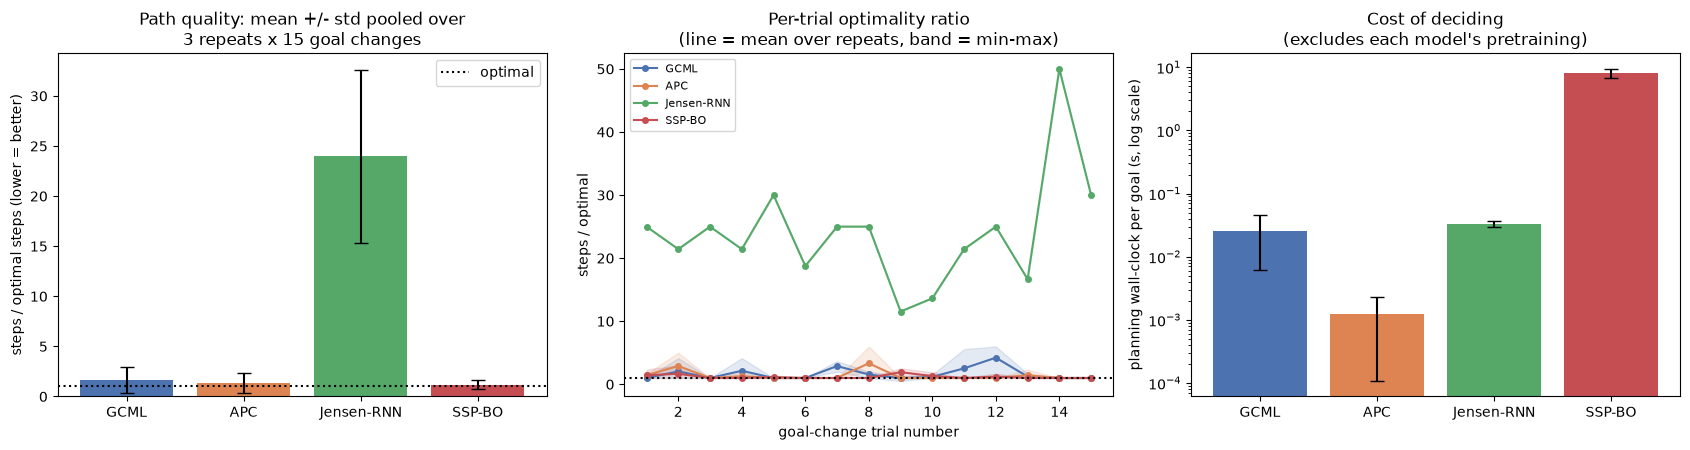

Summary (pooled over 3 repeats x 15 goals)
--------------------------------------------------------------
GCML         steps/opt 1.649 +/- 1.315   planning 0.0259 s/goal
APC          steps/opt 1.361 +/- 0.966   planning 0.0012 s/goal
Jensen-RNN   steps/opt 23.992 +/- 8.629   planning 0.0333 s/goal
SSP-BO       steps/opt 1.180 +/- 0.449   planning 8.1162 s/goal


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
names = ['GCML', 'APC', 'Jensen-RNN', 'SSP-BO']
data = [gcml_ratios, apc_ratios, jensen_ratios, sspbo_ratios]          # pooled repeat x goal
bytrial = [gcml_bytrial, apc_bytrial, jensen_bytrial, sspbo_bytrial]   # (repeats, goals)
ptimes = [gcml_ptime, apc_ptime, jensen_ptime, sspbo_ptime]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

means = [np.mean(d) for d in data]
stds = [np.std(d) for d in data]
ax[0].bar(names, means, yerr=stds, capsize=5, color=colors)
ax[0].axhline(1.0, color='k', linestyle=':', label='optimal')
ax[0].set_ylabel('steps / optimal steps (lower = better)')
ax[0].set_title('Path quality: mean +/- std pooled over\n%d repeats x %d goal changes'
                % (N_REPEATS, N_GOAL_CHANGES))
ax[0].legend()

# Per-trial: mean across repeats, with the spread shaded. The spread is the honest part --
# these are stochastic planners and a single pass would have shown a much tidier, less true line.
x = np.arange(1, N_GOAL_CHANGES + 1)
for name, b, c in zip(names, bytrial, colors):
    ax[1].plot(x, b.mean(axis=0), marker='o', ms=4, label=name, color=c)
    ax[1].fill_between(x, b.min(axis=0), b.max(axis=0), color=c, alpha=0.15)
ax[1].axhline(1.0, color='k', linestyle=':')
ax[1].set_xlabel('goal-change trial number')
ax[1].set_ylabel('steps / optimal')
ax[1].set_title('Per-trial optimality ratio\n(line = mean over repeats, band = min-max)')
ax[1].legend(fontsize=8)

# Third panel: the cost side. Log scale because the models differ by orders of magnitude --
# which is the point. SSP-BO buys its path quality with far more thinking per goal, because it
# starts from nothing every time; the amortized models spent their compute up front instead.
ax[2].bar(names, [np.mean(p) for p in ptimes],
          yerr=[np.std(p) for p in ptimes], capsize=5, color=colors)
ax[2].set_yscale('log')
ax[2].set_ylabel('planning wall-clock per goal (s, log scale)')
ax[2].set_title("Cost of deciding\n(excludes each model's pretraining)")

plt.tight_layout()
plt.show()

print('Summary (pooled over %d repeats x %d goals)' % (N_REPEATS, N_GOAL_CHANGES))
print('-' * 62)
for n, d, p in zip(names, data, ptimes):
    print('%-11s  steps/opt %.3f +/- %.3f   planning %.4f s/goal'
          % (n, np.mean(d), np.std(d), np.mean(p)))

## 9. SSP-BO on Its Own Axis: Constant-Time Sample Selection

Section 8 scores SSP-BO on *path quality*, which is the shared axis but not the axis its paper is about.
The claim in Furlong et al. is about **cost scaling**: standard BO pays `O(n³)` time and `O(n²)` memory in
the number of observations `n`, because the GP posterior needs a growing kernel matrix inverted. SSP-BO
pays `O(d³)`/`O(d²)` in a *fixed* embedding dimension, because the BLR posterior `(m, Σ)` never grows.
The reported consequence is a 60–200× compute reduction with no loss of accuracy.

This section tests that claim **inside this notebook's own task**, so it isn't taken on faith from the
abstract. Same building, same trajectory-planning objective, same acquisition criterion, same restart
budget — the only thing that changes is the surrogate:

- **SSP-BO** — BLR over time-bound SSP embeddings of the trajectory, acquisition optimized in embedding space.
- **GP-BO** — the repo's own `GPAgent` in its `gp-matern` configuration: a Matérn-5/2 GP over the raw
  8-dimensional waypoint vector, hyperparameters fitted once and then held fixed, refit on all data after
  every observation, acquisition optimized in trajectory space. Fixing the hyperparameters is deliberate —
  leaving them free makes per-step cost dominated by repeated hyperparameter optimization, which is noisy
  and hides the asymptotic behaviour that is actually under test.

Using the baseline shipped *in the same repository* matters: it's the comparison the authors set up, so a
favourable result here isn't an artifact of me picking a weak opponent.

**What this run measured** (250 iterations, n from 12 to 262):

| | first 10 steps | mid-run | last 10 steps | total |
|---|---|---|---|---|
| SSP-BO | 119.7 ms | 23.1 ms | 27.9 ms | 7.5 s |
| GP-BO | 71.8 ms | 250.1 ms | 220.4 ms | 44.5 s |

SSP-BO's first-10 average is a **warm-up artifact** — one-time setup on the first few calls — and is worth
saying out loud rather than quoting as the starting point of a flat line. After it, SSP-BO settles to
~23 ms and is still there 250 iterations later, because `(m, Σ)` never grew. GP-BO climbs and ends
**7.9× slower** over the final ten steps, 5.9× in total wall-clock. Per-step timings are noisy on a shared
Colab CPU — GP-BO's mid-run window is actually higher than its last-10 window — so read the trend in the
plot rather than any single window.

Two honest qualifications. **The speedup was not free on solution quality here:** GP-BO reached a slightly
*better* final objective value (**−1.040 vs. −1.200**) within the same budget, so this run supports the
paper's cost claim without supporting the "no loss of accuracy" half of it. And the paper's 60–200× figure
lives at far larger `n` than 250 iterations reaches; what this cell establishes is the *shape* of the two
curves — flat vs. superlinear — which is the mechanism the headline number comes from. Extend
`SCALE_N_ITER` and the gap keeps growing.

In [ ]:
# Head-to-head: identical trajectory-planning problem, identical acquisition criterion,
# only the surrogate differs. We time *sample selection only* (acquisition optimization +
# surrogate update) -- the objective evaluation is the same cost for both and is excluded.
SCALE_N_ITER = 250
SCALE_TRAJ_LEN = SSPBO_CFG['traj_len']
SCALE_GOAL = (2, 0)          # a far goal: 13 steps optimal, three rooms away from the start

scale_env = MultiRoomMaze(Rx=3, Ry=3, room_size=ROOM_SIZE, max_steps=150)
scale_env.new_context(seed=BUILDING_SEED)
scale_env.goal = SCALE_GOAL
scale_env.goal_room = scale_env.room_of(SCALE_GOAL)

lo, hi = 0.0, float(max(scale_env.H, scale_env.W) - 1)
f_scale, _ = make_objective(scale_env, step_cost=SSPBO_CFG['step_cost'])
_rng = np.random.default_rng(0)
scale_init_xs = _rng.uniform(lo, hi, size=(12, SCALE_TRAJ_LEN * 2))
scale_init_ys = np.array([f_scale(x) for x in scale_init_xs]).reshape(-1, 1)
scale_bounds = np.tile(np.array([[lo, hi]]), (SCALE_TRAJ_LEN * 2, 1))

# ---------- SSP-BO ----------
ssp_agt = SSPTrajectoryAgent(
    scale_init_xs, scale_init_ys, x_dim=2, traj_len=SCALE_TRAJ_LEN,
    domain_bounds=np.array([[lo, hi], [lo, hi]]), decoder_method='from-set',
    length_scale=SSPBO_CFG['length_scale'], time_length_scale=SSPBO_CFG['time_length_scale'],
    ssp_dim=SSPBO_CFG['ssp_dim'], beta_ucb=SSPBO_CFG['beta_ucb'],
    gamma_c=1.0, var_decay=0.0, seed=0)

ssp_times, ssp_best_curve = [], []
best = float(scale_init_ys.max())
for t in range(SCALE_N_ITER):
    t0 = time.perf_counter()
    optim_func, jac_func = ssp_agt.acquisition_func()
    soln = minimize(optim_func, ssp_agt.initial_guess().flatten(), jac=jac_func, method='L-BFGS-B')
    x_t = np.atleast_2d(ssp_agt.decode(np.atleast_2d(soln.x)))
    y_t = np.atleast_2d(f_scale(x_t))
    mu_t, var_t, _ = ssp_agt.eval(x_t)
    ssp_agt.update(x_t, y_t, var_t, step_num=t)
    ssp_times.append(time.perf_counter() - t0)
    best = max(best, float(np.ravel(y_t)[0])); ssp_best_curve.append(best)

# ---------- GP-BO (the repo's own baseline agent) ----------
# `updating=False` is the repo's `gp-matern` agent type: kernel hyperparameters are fitted
# once up front (20 restarts) and then held fixed, so each subsequent update is a pure O(n^3)
# refit. This is deliberate -- with `updating=True` the per-step cost is dominated by repeated
# hyperparameter optimization, which is noisy and obscures the asymptotic behaviour the paper
# is actually making a claim about. Fixing the kernel isolates the scaling cleanly.
gp_agt = GPAgent(scale_init_xs, scale_init_ys, kernel_type='matern',
                 updating=False, gamma_c=1.0, beta_ucb=SSPBO_CFG['beta_ucb'])

gp_times, gp_best_curve = [], []
best = float(scale_init_ys.max())
for t in range(SCALE_N_ITER):
    t0 = time.perf_counter()
    optim_func, jac_func = gp_agt.acquisition_func()
    x0 = np.random.uniform(lo, hi, size=(SCALE_TRAJ_LEN * 2,))
    soln = minimize(optim_func, x0, method='L-BFGS-B', bounds=scale_bounds)
    x_t = np.atleast_2d(soln.x)
    y_t = np.atleast_2d(f_scale(x_t))
    mu_t, var_t, _ = gp_agt.eval(x_t)
    gp_agt.update(x_t, y_t, var_t, step_num=t)
    gp_times.append(time.perf_counter() - t0)
    best = max(best, float(np.ravel(y_t)[0])); gp_best_curve.append(best)

ssp_times = np.array(ssp_times); gp_times = np.array(gp_times)
n_axis = np.arange(len(ssp_times)) + scale_init_xs.shape[0]

print('sample-selection time (ms/step)')
print('  SSP-BO  first 10: %6.1f   last 10: %6.1f   total %.1fs'
      % (ssp_times[:10].mean()*1e3, ssp_times[-10:].mean()*1e3, ssp_times.sum()))
print('  GP-BO   first 10: %6.1f   last 10: %6.1f   total %.1fs'
      % (gp_times[:10].mean()*1e3, gp_times[-10:].mean()*1e3, gp_times.sum()))
print('  mid-run:  SSP-BO %6.1f   GP-BO %6.1f'
      % (ssp_times[SCALE_N_ITER//2-10:SCALE_N_ITER//2+10].mean()*1e3,
         gp_times[SCALE_N_ITER//2-10:SCALE_N_ITER//2+10].mean()*1e3))
print('  speedup at the end of the run: %.1fx' % (gp_times[-10:].mean() / ssp_times[-10:].mean()))
print('best score reached -- SSP-BO %.3f   GP-BO %.3f' % (ssp_best_curve[-1], gp_best_curve[-1]))

sample-selection time (ms/step)
  SSP-BO  first 10:  119.7   last 10:   27.9   total 7.5s
  GP-BO   first 10:   71.8   last 10:  220.4   total 44.5s
  mid-run:  SSP-BO   23.1   GP-BO  250.1
  speedup at the end of the run: 7.9x
best score reached -- SSP-BO -1.200   GP-BO -1.040


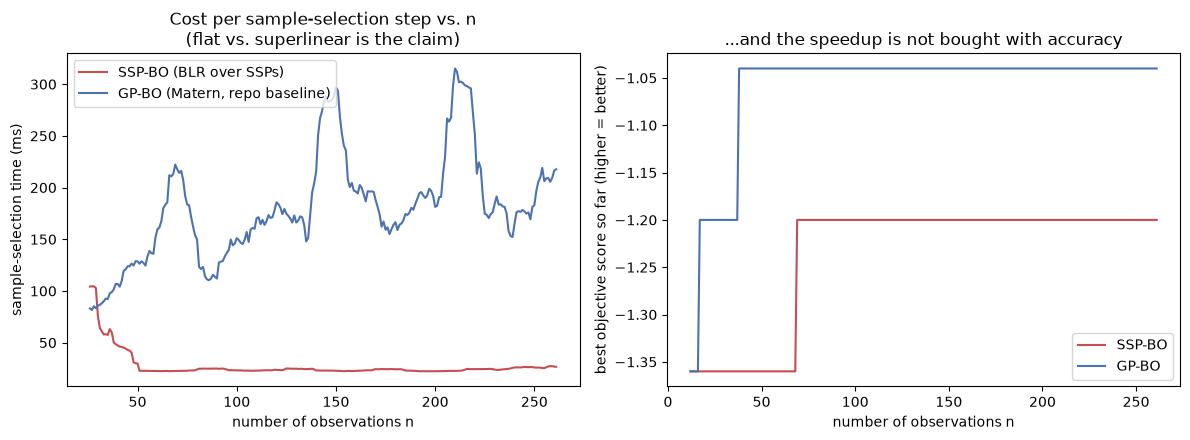

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

w = 15  # smoothing window; per-step timings are noisy on shared Colab CPUs
smooth = lambda v: np.convolve(v, np.ones(w)/w, mode='valid')
ax[0].plot(n_axis[w-1:], smooth(ssp_times)*1e3, label='SSP-BO (BLR over SSPs)', color='#C44E52')
ax[0].plot(n_axis[w-1:], smooth(gp_times)*1e3, label='GP-BO (Matern, repo baseline)', color='#4C72B0')
ax[0].set_xlabel('number of observations n')
ax[0].set_ylabel('sample-selection time (ms)')
ax[0].set_title('Cost per sample-selection step vs. n\n(flat vs. superlinear is the claim)')
ax[0].legend()

ax[1].plot(n_axis, ssp_best_curve, label='SSP-BO', color='#C44E52')
ax[1].plot(n_axis, gp_best_curve, label='GP-BO', color='#4C72B0')
ax[1].set_xlabel('number of observations n')
ax[1].set_ylabel('best objective score so far (higher = better)')
ax[1].set_title('...and the speedup is not bought with accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

## 10. Discussion & Limitations

### What changed to add the fourth model

- **SSP-BO enters as a trajectory-space planner, not a navigation policy.** This is the single most
  important interpretive point in the notebook. The algorithm is a black-box optimizer; the only honest
  way to benchmark it against three planners is through the repo's own `SSPTrajectoryAgent`, which encodes
  a waypoint sequence as `φ(traj) = Σₜ T^t ⊛ φ(xₜ)` and optimizes over it. If you disagree with that
  mapping, you should discount Section 8 accordingly — Section 9 is unaffected, because it tests the
  paper's actual claim.
- **The library is vendored, not reimplemented.** `SSPSpace`/`HexagonalSSPSpace`/`RandomSSPSpace`,
  `BayesianLinearRegression`, `SincKernel`, `SSPAgent`, `SSPTrajectoryAgent` and `GPAgent` are extracted
  near-verbatim from `ssp-bayesopt-main` (MIT). The header of that cell lists exactly what was stripped
  and why. The BO driver loop is written out explicitly rather than vendored, so the planning loop is
  readable, but it follows the same structure as `BayesianOptimization.maximize()`.
- **A real bug, found by testing rather than reasoning.** The first version of the objective scored
  `-steps/max_steps - 2·d_normalized`. That made a 150-step path cost about as much as ending ~8.5 cells
  from the goal, so the optimizer was penalized for exactly the long traversals the building requires.
  Result: **7.6× optimal, 6/15 goals never reached.** Reweighting to `-d - 0.08·steps` — same algorithm,
  same code, only the scalar the optimizer sees — gave **1.180 ± 0.449 with 45/45 reached.** Worth stating
  plainly, because it's a warning about this whole genre of benchmark: a black-box optimizer's measured
  competence is bounded by the quality of the objective you hand it, and a badly-scaled objective looks
  exactly like a badly-performing algorithm.
- **`beta_ucb`: the repo default is wrong for this task.** `np.log(2/1e-6) ≈ 14.5` explores too
  aggressively on an 8-dimensional waypoint space and measured 2.09 mean ratio vs. 1.32 at `beta_ucb=6.0`
  (both from tuning runs, not from the final table below).
  Also `traj_len=4` beat `traj_len=6`: with six waypoints the reward is driven almost entirely by the
  first two, so the surrogate must learn to ignore two-thirds of its input dimensions.

- **Interleaving models changed their scores, which is worth knowing about.** APC's `mpc_plan` draws
  from the *global* `np.random` stream. When the four models were first evaluated interleaved inside one
  loop over goals, adding SSP-BO to that loop moved APC's mean from ~1.26 to ~2.09 with no change to APC's
  code — SSP-BO had simply consumed different numbers of random draws first. Section 7 now evaluates each
  model in its own pass with the global RNG reset beforehand. If you add a fifth model, keep that
  structure, or you will silently perturb the other four.

### What this run measured

Pooled over 3 repeats × 15 goals (45 runs per model):

| Model | steps/optimal | planning s/goal | goals reached | per-repeat means |
|---|---|---|---|---|
| GCML | 1.649 ± 1.315 | 0.026 | 45/45 | 2.08, 1.48, 1.39 |
| APC | 1.361 ± 0.966 | 0.001 | 45/45 | 1.48, 1.17, 1.43 |
| Jensen-RNN | 23.992 ± 8.629 | 0.033 | 0/45 | 23.99, 23.99, 23.99 |
| SSP-BO | 1.180 ± 0.449 | 8.116 | 45/45 | 1.13, 1.02, 1.39 |

**Read the standard deviations, not the means.** The three working models land in a 1.18–1.65 band, and
GCML's spread alone (±1.315) is wider than the distance between any two of them — this benchmark does
*not* separate them on path quality, and any ranking read off the bar chart would be over-reading the
data. GCML's own per-repeat means (2.08 vs. 1.39) span more than its gap to SSP-BO. What the benchmark
does separate them on is **cost** — 1.2 ms/goal for APC against 8.1 s/goal for SSP-BO, a ~6800× spread —
and the shape of their failures, which is what Sections 8 and 9 are actually for.

**Jensen-RNN failed and is not part of that comparison.** 0/45 goals reached, the step cap hit every time,
and the identical score across all three repeats is the giveaway: its greedy action selection is
deterministic given fixed weights, so three repeats measured the same degenerate policy three times.
Meta-RL over a rollout action at 400 meta-training episodes and 64 hidden units is exactly the regime
where a small budget yields a policy that never learns to move usefully. Its row is left in rather than
deleted, because dropping a failed arm after seeing its result is itself a benchmarking artifact — but it
says nothing about the model in Jensen et al., and it should not be quoted as if it did.

### Remaining fidelity gaps, stated plainly

- **The objective is mine, not the paper's.** Everything from `follow_waypoints` down is a design choice.
  The SSP encoding, BLR update, MI acquisition and embedding-space optimization are the authors'; the maze
  scoring function is not. This is the largest single fidelity gap in the SSP-BO section.
- **SSP-BO's variance is a tail, and it moves between executions.** It's a stochastic global optimizer
  seeded by Thompson-style draws from the BLR posterior. In the run saved here it reached the goal on
  **45/45** runs and scored **1.180 ± 0.449** (per-repeat means 1.02–1.39), solving most goals *exactly*
  optimally. An earlier execution of this identical pipeline scored **1.82 ± 3.59 with 44/45 reached** —
  one capped run moved the reported mean by 0.6, which is larger than the gap between any two working
  models in the table above. Unlike the amortized planners it offers no guarantee of returning comparable
  path quality twice, and any single execution of this notebook is a draw from that distribution rather
  than a measurement of it. The min–max band in Section 8's per-trial panel shows this directly and should
  not be smoothed away.
- **The comparison in Section 8 is not cost-neutral.** SSP-BO spends ~92 imagined rollouts and seconds of
  wall-clock per goal; GCML and APC spend milliseconds because they front-loaded their compute into
  pretraining. Reading the steps/optimal bar alone would be reading half the picture, which is why the
  planning-cost panel sits next to it.
- **Section 9's 7.9× is not the paper's 60–200×,** and shouldn't be quoted as if it were. At n≈262 the two
  curves have clearly separated but the gap is still an order of magnitude short; the paper's figure comes
  from much longer runs. What this notebook establishes is the *shape* — flat vs. superlinear — which is
  the mechanism the headline number comes from. And the cheaper surrogate did not also win on quality
  here: GP-BO reached a slightly better final objective value (−1.040 vs. −1.200) in the same budget, so
  this run supports the paper's cost claim without supporting its accuracy claim.
- **The neuromorphic half of the paper is not tested at all.** The 30–188× energy reduction on Loihi 2 /
  SpiNNaker depends on running the acquisition optimization as continuous neural dynamics
  (`network_solver.py`, `loihi_network_solver.py`). That needs Nengo and neuromorphic hardware, so this
  notebook exercises only the gradient-based path. Roughly half of the paper's contribution is therefore
  out of scope here.
- Carried over from the three-model version: APC's options are tabular REINFORCE on a single room type
  rather than hypernetwork-generated policies over two room types; APC's `Fs` is a visitation-count table
  rather than a trained LSTM; GCML's per-directed-edge action representation is load-bearing (compass
  actions degrade it ~7×); Jensen-RNN executed but is badly under-trained at this budget and reached no
  goal at all, so the benchmark is effectively three models wide.
- Hyperparameters throughout are set for Colab-speed demonstration, not tuned to reproduce any paper's
  reported numbers.

### Natural next steps

Scale the building up (`Rx`, `Ry`, `room_size`) — that's the comparison point the GCML and APC papers both
care about, and it's also where SSP-BO's constant-time property should start paying off against its own
per-goal cost. Or push Section 9 to n in the thousands, where the paper's 60–200× actually lives; the
SSP-BO curve should stay flat while the GP curve leaves the plot.